# Dual-Timescale Customer Behaviour Modelling — Reproducible Analysis

This notebook reproduces the primary Instacart experiment and then groups the reviewer-requested checks in a separate section at the end.

**Recommended run order**
1. Setup and environment
2. Load and validate the raw data
3. Build the order-level target and engineered features
4. Explore the modelling dataset
5. Create the user-disjoint train/test split
6. Handle class imbalance on the training set only
7. Train traditional baselines
8. Define and train the neural models
9. Run cross-validation and statistical testing
10. Produce the main figures and explainability outputs
11. Run reviewer-requested supplementary checks

For GitHub, place the Instacart CSV files in `data/`, or set the `INSTACART_DATA_DIR` environment variable. Outputs are written to `outputs/` by default.

## How to read this notebook

The notebook is organised in execution order so that a reader can follow the full analysis from raw Instacart files to the manuscript-facing results. Code comments explain **why** each major step is performed, what data enter the step, and how the output is used. The primary experiment is kept separate from reviewer-requested supplementary analyses so that retrospective checks do not appear to be part of primary model selection.

**Important interpretation:** the order-level target represents whether another observed order follows the current order for the same customer. The SHAP analysis explains the engineered long-term features of the Gradient Boosting baseline; it does not directly explain the hidden representations of the LSTM or the fused Dual-Timescale network.

### Notebook flow
**Data loading → target construction → feature engineering → EDA and EDA graphs → user-disjoint train/test split → imbalance handling → traditional baselines → deep-learning models → holdout evaluation → grouped cross-validation and statistical testing → explainability → reviewer-requested supplementary robustness analyses.**


> **Reviewer cross-reference:** The exact Pearson correlation matrix and heatmap requested during review are presented earlier in the **Exploratory Data Analysis** section because they describe input-feature relationships and do not depend on a trained model. Model-dependent analyses, including tree-based feature importance and SHAP, remain after model training.


## Public repository note

This public version uses repository-relative paths. Place the Instacart CSV files in `data/`, or set `INSTACART_DATA_DIR`. Generated tables, figures, and checkpoints are written to `outputs/`. Retained outputs document the completed reference run; execution times are hardware-dependent.


## 1. Setup, paths, seeds, and experiment settings


In [1]:
# -----------------------------------------------------------------------------
# REPRODUCIBILITY SETUP
# Imports the libraries used throughout the analysis, defines project/data/output
# locations, fixes random seeds, and stores the main experimental settings.
# Keeping these values in one place makes the notebook easier to reproduce and
# prevents hidden configuration changes between experiments.
# -----------------------------------------------------------------------------
import os

import sys

import platform

import time

import gc

import json

import pickle

import importlib.metadata as importlib_metadata

from pathlib import Path

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd()

DATA_DIR = Path(os.getenv("INSTACART_DATA_DIR", PROJECT_DIR / "data"))

OUT_DIR = Path(os.getenv("DUAL_TS_OUTPUT_DIR", PROJECT_DIR / "outputs"))

FIG_DIR = OUT_DIR / "figures"

TAB_DIR = OUT_DIR / "tables"

CKPT_DIR = OUT_DIR / "checkpoints"

OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR.mkdir(parents=True, exist_ok=True)

TAB_DIR.mkdir(parents=True, exist_ok=True)

CKPT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

TEST_SIZE = 0.30

CV_FOLDS = 10

MAIN_T = 50

BATCH_SIZE = 64

LR_DL = 1e-3

EPOCHS_HOLDOUT = 10

EPOCHS_CV = 5

FIXED_THRESHOLD = 0.50

TRAIN_NEGATIVE_SHARE = 0.25

CHUNK_SIZE = 2_000_000

N_JOBS = max(1, (os.cpu_count() or 2) - 1)

BOOTSTRAP_ITERATIONS = 2000
STAT_ALPHA = 0.05

RUN_T_SENSITIVITY = True

T_SENSITIVITY_VALUES = [5, 10, 20, 30, 50]

RUN_SUPPLEMENTARY_ML_FAIRNESS = True

RUN_ORIGINAL_SAMPLER_AUDIT = True

RUN_CORRECTED_IMBALANCE_ROBUSTNESS = True

RUN_BASELINE_CV = True

RUN_DUAL_CV = True

RUN_SHAP = True

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUT_DIR:", OUT_DIR)

print("MAIN_T:", MAIN_T)
print("BATCH_SIZE:", BATCH_SIZE)
print("LR_DL:", LR_DL)
print("EPOCHS_HOLDOUT:", EPOCHS_HOLDOUT)
print("EPOCHS_CV:", EPOCHS_CV)


PROJECT_DIR: C:\Users\t_jaf
DATA_DIR: C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\InstaCart
OUT_DIR: C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production
MAIN_T: 50
BATCH_SIZE: 64
LR_DL: 0.001
EPOCHS_HOLDOUT: 10
EPOCHS_CV: 5


## 2. Reproducibility environment


In [2]:
# -----------------------------------------------------------------------------
# ENVIRONMENT REPORT
# Records Python, operating-system, hardware, and package-version information.
# These details help another researcher reproduce the software environment used
# to generate the manuscript results.
# -----------------------------------------------------------------------------
packages_to_report = [
    "numpy",
    "pandas",
    "matplotlib",
    "scipy",
    "scikit-learn",
    "torch",
    "shap",
]

package_versions = {}

for package_name in packages_to_report:

    try:
        package_versions[package_name] = importlib_metadata.version(package_name)

    except importlib_metadata.PackageNotFoundError:
        package_versions[package_name] = "NOT INSTALLED"

environment_report = {
    "python_version": sys.version.replace("\n", " "),
    "operating_system": platform.platform(),
    "processor": platform.processor(),
    "cpu_count": os.cpu_count(),
    "packages": package_versions,
}

with open(OUT_DIR / "environment_report.json", "w", encoding="utf-8") as file:
    json.dump(environment_report, file, indent=2)

package_table = pd.DataFrame(
    [{"Package": name, "Version": version} for name, version in package_versions.items()]
)

package_table.to_csv(TAB_DIR / "package_versions.csv", index=False)

display(package_table)

print("Python:", environment_report["python_version"])
print("Operating system:", environment_report["operating_system"])
print("Processor:", environment_report["processor"])
print("CPU count:", environment_report["cpu_count"])


,Package,Version
0,numpy,2.2.5
1,pandas,2.3.3
2,matplotlib,3.10.8
3,scipy,1.15.3
4,scikit-learn,1.7.1
5,torch,2.10.0
6,shap,0.49.1


Python: 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]
Operating system: Windows-10-10.0.26200-SP0
Processor: Intel64 Family 6 Model 140 Stepping 1, GenuineIntel
CPU count: 8


## 3. Utility functions and checkpoints


In [3]:
# -----------------------------------------------------------------------------
# REUSABLE I/O AND CHECKPOINT HELPERS
# Defines small utility functions for saving/loading intermediate objects and
# tables. Checkpoints reduce repeated computation without changing the analysis.
# -----------------------------------------------------------------------------
def save_obj(obj, name):

    path = CKPT_DIR / f"{name}.pkl"

    with open(path, "wb") as file:

        pickle.dump(obj, file, protocol=pickle.HIGHEST_PROTOCOL)

    print("[saved]", path)

def load_obj(name):

    path = CKPT_DIR / f"{name}.pkl"

    if not path.exists():
        return None

    with open(path, "rb") as file:

        obj = pickle.load(file)

    print("[loaded]", path)

    return obj

def save_table(dataframe, name, index=False):

    path = TAB_DIR / f"{name}.csv"

    dataframe.to_csv(path, index=index)

    print("[saved]", path)


## 4. Load and validate the Instacart data


In [4]:
# -----------------------------------------------------------------------------
# LOAD RAW INSTACART TABLES
# Builds the expected file paths, verifies that required files exist, and loads
# the order-level and order-product data used by the study.
# -----------------------------------------------------------------------------
ORDERS_PATH = DATA_DIR / "orders.csv"

PRIOR_PATH = DATA_DIR / "order_products__prior.csv"

TRAIN_PATH = DATA_DIR / "order_products__train.csv"

PRODUCTS_PATH = DATA_DIR / "products.csv"

AISLES_PATH = DATA_DIR / "aisles.csv"

DEPTS_PATH = DATA_DIR / "departments.csv"

required_files = {
    "orders.csv": ORDERS_PATH,
    "order_products__prior.csv": PRIOR_PATH,
    "order_products__train.csv": TRAIN_PATH,
    "products.csv": PRODUCTS_PATH,
    "aisles.csv": AISLES_PATH,
    "departments.csv": DEPTS_PATH,
}

missing_files = [name for name, path in required_files.items() if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Missing Instacart file(s) in DATA_DIR: " + ", ".join(missing_files)
    )

orders_dtypes = {
    "order_id": "int32",
    "user_id": "int32",
    "eval_set": "category",
    "order_number": "int16",
    "order_dow": "int8",
    "order_hour_of_day": "int8",
    "days_since_prior_order": "float32",
}

op_dtypes = {
    "order_id": "int32",
    "product_id": "int32",
    "add_to_cart_order": "int16",
    "reordered": "int8",
}

products_dtypes = {
    "product_id": "int32",
    "product_name": "string",
    "aisle_id": "int16",
    "department_id": "int16",
}

aisles_dtypes = {
    "aisle_id": "int16",
    "aisle": "string",
}

depts_dtypes = {
    "department_id": "int16",
    "department": "string",
}

load_start = time.time()

orders = pd.read_csv(ORDERS_PATH, dtype=orders_dtypes)

orders["days_since_prior_order"] = (
    orders["days_since_prior_order"].fillna(0).astype("float32")
)

products = pd.read_csv(PRODUCTS_PATH, dtype=products_dtypes)

aisles = pd.read_csv(AISLES_PATH, dtype=aisles_dtypes)

departments = pd.read_csv(DEPTS_PATH, dtype=depts_dtypes)

load_seconds = time.time() - load_start

print("Loaded in", round(load_seconds, 2), "seconds")

print("orders:", orders.shape)
print("products:", products.shape)
print("aisles:", aisles.shape)
print("departments:", departments.shape)

display(orders.head())


Loaded in 4.53 seconds
orders: (3421083, 7)
products: (49688, 4)
aisles: (134, 2)
departments: (21, 2)


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,0.0
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [5]:
# -----------------------------------------------------------------------------
# RAW-DATA VALIDATION
# Summarises missing values and performs basic integrity checks before feature
# engineering. This makes data-quality assumptions visible to the reader.
# -----------------------------------------------------------------------------
def missing_table(dataframe, table_name):

    missing = dataframe.isna().sum().sort_values(ascending=False)

    missing = missing[missing > 0]

    result = missing.reset_index()

    result.columns = ["column", "missing_count"]

    result.insert(0, "table", table_name)

    return result

def duplicate_count(dataframe):

    return int(dataframe.duplicated().sum())

missing_values = pd.concat(
    [
        missing_table(orders, "orders"),
        missing_table(products, "products"),
        missing_table(aisles, "aisles"),
        missing_table(departments, "departments"),
    ],
    ignore_index=True,
)

if len(missing_values) == 0:
    missing_values = pd.DataFrame(
        {"table": ["(all)"], "column": ["None"], "missing_count": [0]}
    )

save_table(missing_values, "missing_values_summary")

duplicate_summary = pd.DataFrame(
    {
        "table": ["orders", "products", "aisles", "departments"],
        "duplicate_rows": [
            duplicate_count(orders),
            duplicate_count(products),
            duplicate_count(aisles),
            duplicate_count(departments),
        ],
    }
)

save_table(duplicate_summary, "duplicate_summary")

orders["order_dow"] = orders["order_dow"].clip(0, 6).astype("int8")

orders["order_hour_of_day"] = orders["order_hour_of_day"].clip(0, 23).astype("int8")

orders["days_since_prior_order"] = (
    orders["days_since_prior_order"].clip(lower=0).astype("float32")
)

integrity_checks = pd.DataFrame(
    {
        "check": [
            "orders.order_id unique",
            "products.product_id unique",
        ],
        "passed": [
            orders["order_id"].nunique() == len(orders),
            products["product_id"].nunique() == len(products),
        ],
    }
)

save_table(integrity_checks, "integrity_checks")

display(missing_values)
display(duplicate_summary)
display(integrity_checks)


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\missing_values_summary.csv
[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\duplicate_summary.csv
[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\integrity_checks.csv


,table,column,missing_count
0,(all),None,0


,table,duplicate_rows
0,orders,0
1,products,0
2,aisles,0
3,departments,0


,check,passed
0,orders.order_id unique,True
1,products.product_id unique,True


## 5. Define the order-level outcome

`y_order = 1` means a later observed order exists for the same customer.  
`y_order = 0` marks the customer's final observed order in the dataset.


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\label_definition_and_distribution.csv


,y_order,count,percentage,operational_definition
0,0,206209,6.027594,Current order is the user's last observed order
1,1,3214874,93.972406,At least one later observed order exists


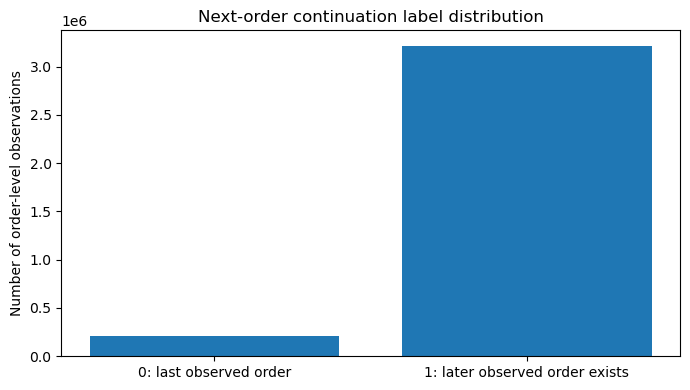

In [6]:
# -----------------------------------------------------------------------------
# DEFINE THE ORDER-LEVEL PREDICTION TARGET
# For each customer, the maximum observed order_number identifies the final
# observed order. y_order = 1 when another observed order follows the current
# order; y_order = 0 for the customer's final observed order.
# This is therefore repeat-order/purchase-continuation prediction, not first-time
# customer acquisition.
# -----------------------------------------------------------------------------
user_max = (
    orders.groupby("user_id")["order_number"]
    .max()
    .rename("max_order_number")
    .reset_index()
)

orders = orders.merge(user_max, on="user_id", how="left")

orders["is_last_order"] = (
    orders["order_number"] == orders["max_order_number"]
)

orders["y_order"] = (~orders["is_last_order"]).astype("int8")

label_counts = (
    orders["y_order"]
    .value_counts()
    .sort_index()
    .rename_axis("y_order")
    .reset_index(name="count")
)

label_counts["percentage"] = (
    100.0 * label_counts["count"] / label_counts["count"].sum()
)

label_counts["operational_definition"] = label_counts["y_order"].map(
    {
        0: "Current order is the user's last observed order",
        1: "At least one later observed order exists",
    }
)

save_table(label_counts, "label_definition_and_distribution")

display(label_counts)

plt.figure(figsize=(7, 4))

plt.bar(
    ["0: last observed order", "1: later observed order exists"],
    label_counts["count"].to_numpy(),
)

plt.ylabel("Number of order-level observations")

plt.title("Next-order continuation label distribution")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "label_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## 6. Build order-level basket features


In [7]:
# -----------------------------------------------------------------------------
# CONSTRUCT ORDER-LEVEL BASKET FEATURES
# Aggregates product rows to one row per order to obtain basket_size and
# reorder_ratio. Chunked processing/checkpointing is used because the Instacart
# order-product tables are large.
# -----------------------------------------------------------------------------
BASKET_CACHE = CKPT_DIR / "order_basket_FULL.csv"

def aggregate_order_products(path, chunk_size):

    aggregate = None

    for chunk_number, chunk in enumerate(
        pd.read_csv(path, dtype=op_dtypes, chunksize=chunk_size),
        start=1,
    ):

        temporary = chunk.groupby("order_id").agg(
            basket_size=("product_id", "count"),
            reorder_sum=("reordered", "sum"),
        )

        if aggregate is None:
            aggregate = temporary

        else:
            aggregate = aggregate.add(temporary, fill_value=0)

        print(f"{path.name}: completed chunk {chunk_number}")

        del chunk, temporary

        gc.collect()

    aggregate = aggregate.reset_index()

    aggregate["basket_size"] = aggregate["basket_size"].astype("int32")

    aggregate["reorder_sum"] = aggregate["reorder_sum"].astype("int32")

    return aggregate

if BASKET_CACHE.exists():

    order_basket = pd.read_csv(BASKET_CACHE)

    print("Loaded cached basket features:", order_basket.shape)

else:

    print("Aggregating PRIOR table...")
    basket_prior = aggregate_order_products(PRIOR_PATH, CHUNK_SIZE)

    print("Aggregating TRAIN table...")
    basket_train = aggregate_order_products(TRAIN_PATH, CHUNK_SIZE)

    order_basket = pd.concat(
        [basket_prior, basket_train],
        ignore_index=True,
    )

    order_basket = order_basket.groupby("order_id", as_index=False).agg(
        basket_size=("basket_size", "sum"),
        reorder_sum=("reorder_sum", "sum"),
    )

    order_basket["reorder_ratio"] = (
        order_basket["reorder_sum"] / order_basket["basket_size"]
    )

    order_basket["reorder_ratio"] = (
        order_basket["reorder_ratio"]
        .replace([np.inf, -np.inf], 0)
        .fillna(0)
        .astype("float32")
    )

    order_basket.to_csv(BASKET_CACHE, index=False)

    print("Saved basket cache:", BASKET_CACHE)

display(order_basket.head())


Loaded cached basket features: (3346083, 4)


,order_id,basket_size,reorder_sum,reorder_ratio
0,1,8,4,0.500000
1,2,9,6,0.666667
2,3,8,8,1.000000
3,4,13,12,0.923077
4,5,26,21,0.807692


## 7. Engineer short-term and long-term behavioural features


In [8]:
# -----------------------------------------------------------------------------
# ENGINEER DUAL-TIMESCALE FEATURES
# Merges basket information into the order table, then constructs:
#   Short-term signals: order timing, recency, basket size, reorder ratio.
#   Long-term signals: cumulative order count, inter-order statistics, basket
#   statistics, and cumulative reorder behaviour available up to that point.
# Cumulative features use historical information only, avoiding future leakage.
# -----------------------------------------------------------------------------
orders = orders.merge(
    order_basket[["order_id", "basket_size", "reorder_ratio"]],
    on="order_id",
    how="left",
)

orders["basket_size"] = orders["basket_size"].fillna(0).astype("int32")

orders["reorder_ratio"] = (
    orders["reorder_ratio"].fillna(0).clip(0, 1).astype("float32")
)

orders = orders.sort_values(
    ["user_id", "order_number"]
).reset_index(drop=True)

short_cols = [
    "order_dow",
    "order_hour_of_day",
    "days_since_prior_order",
    "basket_size",
    "reorder_ratio",
]

for column_name in short_cols:
    orders[column_name] = orders[column_name].astype("float32")

orders["cum_order_count"] = (
    orders.groupby("user_id").cumcount() + 1
)

orders["cum_avg_days"] = (
    orders.groupby("user_id")["days_since_prior_order"]
    .expanding()
    .mean()
    .reset_index(level=0, drop=True)
    .astype("float32")
)

orders["cum_avg_basket"] = (
    orders.groupby("user_id")["basket_size"]
    .expanding()
    .mean()
    .reset_index(level=0, drop=True)
    .astype("float32")
)

orders["cum_reorder_ratio"] = (
    orders.groupby("user_id")["reorder_ratio"]
    .expanding()
    .mean()
    .reset_index(level=0, drop=True)
    .astype("float32")
)

orders["cum_std_days"] = (
    orders.groupby("user_id")["days_since_prior_order"]
    .expanding()
    .std()
    .reset_index(level=0, drop=True)
    .fillna(0)
    .astype("float32")
)

orders["cum_std_basket"] = (
    orders.groupby("user_id")["basket_size"]
    .expanding()
    .std()
    .reset_index(level=0, drop=True)
    .fillna(0)
    .astype("float32")
)

long_cols = [
    "cum_order_count",
    "cum_avg_days",
    "cum_std_days",
    "cum_avg_basket",
    "cum_std_basket",
    "cum_reorder_ratio",
]

all_tabular_cols = short_cols + long_cols

save_table(
    pd.DataFrame({"short_feature": short_cols}),
    "short_feature_list",
)

save_table(
    pd.DataFrame({"long_feature": long_cols}),
    "long_feature_list",
)

display(
    orders[
        ["user_id", "order_number", "y_order"]
        + short_cols
        + long_cols
    ].head(10)
)


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\short_feature_list.csv
[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\long_feature_list.csv


,user_id,order_number,y_order,order_dow,order_hour_of_day,days_since_prior_order,basket_size,reorder_ratio,cum_order_count,cum_avg_days,cum_std_days,cum_avg_basket,cum_std_basket,cum_reorder_ratio
0,1,1,1,2.0,8.0,0.0,5.0,0.000000,1,0.000000,0.000000,5.000000,0.000000,0.000000
1,1,2,1,3.0,7.0,15.0,6.0,0.500000,2,7.500000,10.606602,5.500000,0.707107,0.250000
2,1,3,1,3.0,12.0,21.0,5.0,0.600000,3,12.000000,10.816654,5.333333,0.577350,0.366667
3,1,4,1,4.0,7.0,29.0,5.0,1.000000,4,16.250000,12.257650,5.250000,0.500000,0.525000
4,1,5,1,4.0,15.0,28.0,8.0,0.625000,5,18.600000,11.844831,5.800000,1.303841,0.545000
5,1,6,1,2.0,7.0,19.0,4.0,1.000000,6,18.666666,10.595596,5.500000,1.378405,0.620833
6,1,7,1,1.0,9.0,20.0,5.0,1.000000,7,18.857143,9.685532,5.428571,1.272418,0.675000
7,1,8,1,1.0,14.0,14.0,6.0,0.666667,8,18.250000,9.130013,5.500000,1.195229,0.673958
8,1,9,1,1.0,16.0,0.0,6.0,1.000000,9,16.222221,10.485439,5.555555,1.130388,0.710185
9,1,10,1,4.0,8.0,30.0,9.0,0.666667,10,17.600000,10.803291,5.900000,1.523884,0.705833


## 8. Exploratory data analysis

This section checks the modelling table, target distribution, customer coverage, and feature ranges before any model fitting.


In [9]:
# -----------------------------------------------------------------------------
# EXPLORATORY DATA CHECKS
# Reports modelling-table size, number of customers, target prevalence, and
# feature ranges. These checks document the data entering the modelling stage.
# -----------------------------------------------------------------------------
eda_overview = pd.DataFrame({
    "rows": [len(orders)],
    "users": [orders["user_id"].nunique()],
    "positive_rate": [orders["y_order"].mean()],
    "negative_rate": [1.0 - orders["y_order"].mean()],
    "short_term_features": [len(short_cols)],
    "long_term_features": [len(long_cols)],
})
display(eda_overview)

display(label_counts)

feature_summary = orders[short_cols + long_cols].describe().T
display(feature_summary)
save_table(eda_overview, "eda_overview")
save_table(feature_summary.reset_index().rename(columns={"index": "Feature"}), "feature_summary")


,rows,users,positive_rate,negative_rate,short_term_features,long_term_features
0,3421083,206209,0.939724,0.060276,5,6


,y_order,count,percentage,operational_definition
0,0,206209,6.027594,Current order is the user's last observed order
1,1,3214874,93.972406,At least one later observed order exists


,count,mean,std,min,25%,50%,75%,max
order_dow,3421083.0,2.776219,2.039902,0.00,1.000000,3.000000,5.000000,6.000000
order_hour_of_day,3421083.0,13.452014,4.224759,0.00,10.000000,13.000000,16.000000,23.000000
days_since_prior_order,3421083.0,10.444878,9.296047,0.00,4.000000,7.000000,15.000000,30.000000
basket_size,3421083.0,9.885494,7.587974,0.00,4.000000,8.000000,13.000000,145.000000
reorder_ratio,3421083.0,0.585685,0.342262,0.00,0.333333,0.647059,0.900000,1.000000
cum_order_count,3421083.0,17.154858,17.733164,1.00,5.000000,11.000000,23.000000,100.000000
cum_avg_days,3421083.0,8.676410,5.307220,0.00,4.800000,7.736842,12.142858,27.000000
cum_std_days,3421083.0,6.902606,4.454548,0.00,3.451417,6.207862,9.899495,21.213203
cum_avg_basket,3421083.0,10.038363,5.891806,0.75,5.878788,9.000000,13.000000,101.500000
cum_std_basket,3421083.0,4.018738,2.780982,0.00,2.110579,3.606446,5.478240,72.560318


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\eda_overview.csv
[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\feature_summary.csv


### EDA visualisations

The plots below are intentionally placed with the exploratory analysis so a GitHub reader can inspect the target distribution and relationships among engineered behavioural features **before** model training. The correlation analysis also addresses the reviewer's request for exact long-term feature relationships; it is not a post-training model result.


In [10]:
# -----------------------------------------------------------------------------
# EDA — EXACT LONG-TERM FEATURE CORRELATIONS
# Computes Pearson correlations among the engineered cumulative features and
# saves the full matrix plus the strongest off-diagonal relationship. This makes
# the manuscript's correlation discussion numerically reproducible.
# -----------------------------------------------------------------------------
# `orders` already contains the engineered short- and long-term features at
# this stage. Because this is exploratory correlation analysis, it is computed
# before the user-disjoint train/test split; no model is fitted or tuned here.
correlation_matrix = orders[long_cols].corr(method="pearson")

correlation_matrix.to_csv(
    TAB_DIR / "long_term_correlation_matrix.csv"
)

absolute_matrix = correlation_matrix.abs().copy()

np.fill_diagonal(absolute_matrix.values, np.nan)

max_location = np.unravel_index(
    np.nanargmax(absolute_matrix.to_numpy()),
    absolute_matrix.shape,
)

feature_1 = absolute_matrix.index[max_location[0]]

feature_2 = absolute_matrix.columns[max_location[1]]

pearson_r = correlation_matrix.loc[feature_1, feature_2]

strongest_correlation = pd.DataFrame(
    [
        {
            "feature_1": feature_1,
            "feature_2": feature_2,
            "pearson_r": pearson_r,
            "absolute_r": abs(pearson_r),
        }
    ]
)

save_table(
    strongest_correlation,
    "strongest_long_term_correlation",
)

display(correlation_matrix.round(4))
display(strongest_correlation)


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\strongest_long_term_correlation.csv


,cum_order_count,cum_avg_days,cum_std_days,cum_avg_basket,cum_std_basket,cum_reorder_ratio
cum_order_count,1.0000,-0.2640,-0.3339,-0.0191,0.1785,0.6562
cum_avg_days,-0.2640,1.0000,0.8445,0.0205,0.1478,0.0131
cum_std_days,-0.3339,0.8445,1.0000,-0.0278,0.1100,-0.1860
cum_avg_basket,-0.0191,0.0205,-0.0278,1.0000,0.6020,0.0335
cum_std_basket,0.1785,0.1478,0.1100,0.6020,1.0000,0.2138
cum_reorder_ratio,0.6562,0.0131,-0.1860,0.0335,0.2138,1.0000


,feature_1,feature_2,pearson_r,absolute_r
0,cum_avg_days,cum_std_days,0.844468,0.844468


,cum_order_count,cum_avg_days,cum_std_days,cum_avg_basket,cum_std_basket,cum_reorder_ratio
cum_order_count,1.0000,-0.2640,-0.3339,-0.0191,0.1785,0.6562
cum_avg_days,-0.2640,1.0000,0.8445,0.0205,0.1478,0.0131
cum_std_days,-0.3339,0.8445,1.0000,-0.0278,0.1100,-0.1860
cum_avg_basket,-0.0191,0.0205,-0.0278,1.0000,0.6020,0.0335
cum_std_basket,0.1785,0.1478,0.1100,0.6020,1.0000,0.2138
cum_reorder_ratio,0.6562,0.0131,-0.1860,0.0335,0.2138,1.0000


,feature_1,feature_2,pearson_r,absolute_r
0,cum_avg_days,cum_std_days,0.844468,0.844468


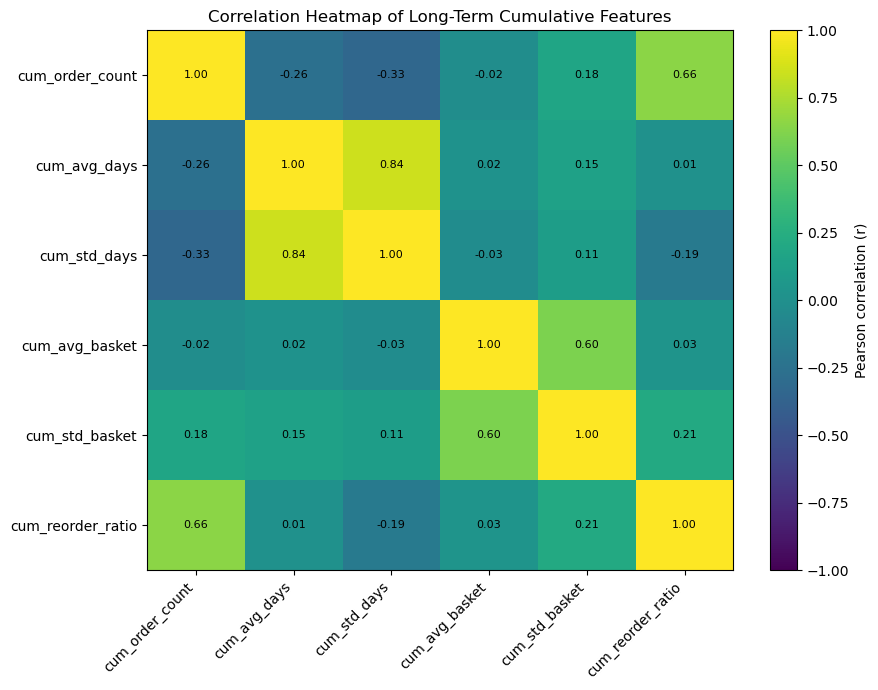

In [11]:
# -----------------------------------------------------------------------------
# EDA — DISPLAY / PLOT CORRELATION RESULTS
# Displays the numerical matrix and creates the reviewer-facing correlation
# heatmap from the same values saved above.
# -----------------------------------------------------------------------------
display(correlation_matrix.round(4))
display(strongest_correlation)

fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(correlation_matrix.to_numpy(), aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(long_cols)))
ax.set_yticks(range(len(long_cols)))
ax.set_xticklabels(long_cols, rotation=45, ha="right")
ax.set_yticklabels(long_cols)

for i in range(len(long_cols)):
    for j in range(len(long_cols)):
        ax.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )

fig.colorbar(image, ax=ax, label="Pearson correlation (r)")
ax.set_title("Correlation Heatmap of Long-Term Cumulative Features")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_long_term_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## 9. User-disjoint train/test split

Users, rather than individual order rows, are split so that the same customer cannot appear in both training and holdout data.


In [12]:
# -----------------------------------------------------------------------------
# USER-DISJOINT HOLDOUT SPLIT
# Splits unique user_id values first and then assigns their order rows to train
# or test. Consequently, no customer's records can appear in both partitions.
# The holdout test set retains the naturally imbalanced class distribution.
# -----------------------------------------------------------------------------
from sklearn.model_selection import train_test_split

unique_users = orders["user_id"].unique()

train_users, test_users = train_test_split(
    unique_users,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
)

train_df = orders[
    orders["user_id"].isin(train_users)
].copy()

test_df = orders[
    orders["user_id"].isin(test_users)
].copy()

overlapping_users = set(train_df["user_id"]).intersection(
    set(test_df["user_id"])
)

assert len(overlapping_users) == 0, "User-level leakage detected."

split_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "users": train_df["user_id"].nunique(),
            "orders": len(train_df),
            "positive_rate": train_df["y_order"].mean(),
            "negative_rate": 1.0 - train_df["y_order"].mean(),
        },
        {
            "split": "test",
            "users": test_df["user_id"].nunique(),
            "orders": len(test_df),
            "positive_rate": test_df["y_order"].mean(),
            "negative_rate": 1.0 - test_df["y_order"].mean(),
        },
    ]
)

save_table(split_summary, "user_disjoint_split_summary")

display(split_summary)

print("Overlapping user IDs:", len(overlapping_users))

save_obj(
    {
        "train_df": train_df,
        "test_df": test_df,
        "short_cols": short_cols,
        "long_cols": long_cols,
        "all_tabular_cols": all_tabular_cols,
    },
    "core_data_after_split",
)


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\user_disjoint_split_summary.csv


,split,users,orders,positive_rate,negative_rate
0,train,144346,2392014,0.939655,0.060345
1,test,61863,1029069,0.939884,0.060116


Overlapping user IDs: 0
[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\checkpoints\core_data_after_split.pkl


## 10. Class-imbalance handling and evaluation metrics

The primary training data are undersampled to a 75/25 positive/negative distribution. The holdout test set keeps its original prevalence. ROC-AUC is the primary metric; PR-AUC, Precision, Recall, F1, and MCC are also reported.


In [13]:
# -----------------------------------------------------------------------------
# IMBALANCE HANDLING + COMMON METRICS
# Creates the primary 75/25 training distribution by random undersampling only
# within the training data. The untouched holdout distribution is preserved.
# Also defines the common evaluation routine used to report ROC-AUC, PR-AUC,
# precision, recall, F1, and MCC consistently across models.
# -----------------------------------------------------------------------------
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    auc,
    average_precision_score,
)

def undersample_to_ratio(
    dataframe,
    target_minority_share=TRAIN_NEGATIVE_SHARE,
    label_col="y_order",
    seed=RANDOM_SEED,
):

    rng = np.random.default_rng(seed)

    labels = dataframe[label_col].to_numpy()

    minority_indices = np.where(labels == 0)[0]

    majority_indices = np.where(labels == 1)[0]

    number_minority = len(minority_indices)

    target_total = int(round(number_minority / target_minority_share))

    target_majority = max(
        0,
        min(
            target_total - number_minority,
            len(majority_indices),
        ),
    )

    sampled_majority = rng.choice(
        majority_indices,
        size=target_majority,
        replace=False,
    )

    kept_indices = np.concatenate(
        [minority_indices, sampled_majority]
    )

    rng.shuffle(kept_indices)

    return dataframe.iloc[kept_indices].copy()

def evaluate_probabilities(
    y_true,
    probabilities,
    threshold=FIXED_THRESHOLD,
):

    predictions = (probabilities >= threshold).astype(int)

    precision_curve, recall_curve, _ = precision_recall_curve(
        y_true,
        probabilities,
    )

    pr_auc_value = auc(
        recall_curve,
        precision_curve,
    )

    return {
        "ROC_AUC": roc_auc_score(y_true, probabilities),
        "PR_AUC": pr_auc_value,
        "Average_Precision": average_precision_score(
            y_true,
            probabilities,
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "MCC": matthews_corrcoef(
            y_true,
            predictions,
        ),
        "Threshold": float(threshold),
    }

train_df_bal = undersample_to_ratio(
    train_df,
    target_minority_share=TRAIN_NEGATIVE_SHARE,
    seed=RANDOM_SEED,
)

balance_summary = pd.DataFrame(
    [
        {
            "dataset": "original_train",
            "rows": len(train_df),
            "positive_rate": train_df["y_order"].mean(),
            "negative_rate": 1.0 - train_df["y_order"].mean(),
        },
        {
            "dataset": "balanced_train_75_25",
            "rows": len(train_df_bal),
            "positive_rate": train_df_bal["y_order"].mean(),
            "negative_rate": 1.0 - train_df_bal["y_order"].mean(),
        },
        {
            "dataset": "untouched_test",
            "rows": len(test_df),
            "positive_rate": test_df["y_order"].mean(),
            "negative_rate": 1.0 - test_df["y_order"].mean(),
        },
    ]
)

save_table(balance_summary, "class_balance_summary")

display(balance_summary)


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\class_balance_summary.csv


,dataset,rows,positive_rate,negative_rate
0,original_train,2392014,0.939655,0.060345
1,balanced_train_75_25,577384,0.750000,0.250000
2,untouched_test,1029069,0.939884,0.060116


## 11. Traditional machine-learning baselines


In [14]:
# -----------------------------------------------------------------------------
# TRADITIONAL MACHINE-LEARNING BASELINES
# Fits Logistic Regression, Random Forest, and Gradient Boosting on the primary
# training partition and evaluates them on the same untouched holdout test set.
# These models provide the non-neural reference against which the proposed model
# is compared.
# -----------------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.base import clone

baseline_models = [
    (
        "Logistic Regression",
        LogisticRegression(
            max_iter=500,
            class_weight="balanced",
            random_state=RANDOM_SEED,
        ),
        True,
    ),
    (
        "Random Forest",
        RandomForestClassifier(
            n_estimators=250,
            n_jobs=N_JOBS,
            random_state=RANDOM_SEED,
            class_weight="balanced_subsample",
        ),
        False,
    ),
    (
        "Gradient Boosting",
        GradientBoostingClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            random_state=RANDOM_SEED,
        ),
        False,
    ),
]

def fit_predict_baseline(
    model,
    X_train,
    y_train,
    X_test,
    scale=False,
):

    scaler = None

    if scale:

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)

        X_test = scaler.transform(X_test)

    training_start = time.perf_counter()

    model.fit(X_train, y_train)

    training_seconds = time.perf_counter() - training_start

    inference_start = time.perf_counter()

    probabilities = model.predict_proba(X_test)[:, 1]

    inference_seconds = time.perf_counter() - inference_start

    return (
        model,
        scaler,
        probabilities,
        training_seconds,
        inference_seconds,
    )

X_train_long = train_df_bal[long_cols].to_numpy(dtype=np.float32)

y_train_long = train_df_bal["y_order"].to_numpy(dtype=np.int64)

X_test_long = test_df[long_cols].to_numpy(dtype=np.float32)

y_test_long = test_df["y_order"].to_numpy(dtype=np.int64)

primary_baseline_rows = []

primary_baseline_store = {}

for model_name, estimator_template, use_scaling in baseline_models:

    estimator = clone(estimator_template)

    (
        fitted_estimator,
        fitted_scaler,
        probabilities,
        training_seconds,
        inference_seconds,
    ) = fit_predict_baseline(
        estimator,
        X_train_long,
        y_train_long,
        X_test_long,
        scale=use_scaling,
    )

    metrics = evaluate_probabilities(
        y_test_long,
        probabilities,
        threshold=FIXED_THRESHOLD,
    )

    metrics["Model"] = model_name

    metrics["Feature_Set"] = "LongOnly_PRIMARY"

    metrics["Training_Time_s"] = training_seconds

    metrics["Inference_Time_s"] = inference_seconds

    metrics["Inference_ms_per_Order"] = (
        1000.0 * inference_seconds / len(y_test_long)
    )

    primary_baseline_rows.append(metrics)

    primary_baseline_store[model_name] = {
        "model": fitted_estimator,
        "scaler": fitted_scaler,
        "probabilities": probabilities,
        "y_true": y_test_long,
    }

    print(
        f"{model_name}: "
        f"ROC-AUC={metrics['ROC_AUC']:.4f}, "
        f"PR-AUC={metrics['PR_AUC']:.4f}, "
        f"F1={metrics['F1']:.4f}, "
        f"MCC={metrics['MCC']:.4f}"
    )

primary_baseline_results = pd.DataFrame(primary_baseline_rows)

primary_baseline_results = primary_baseline_results.sort_values(
    "ROC_AUC",
    ascending=False,
).reset_index(drop=True)

save_table(
    primary_baseline_results,
    "primary_baseline_holdout_metrics",
)

display(primary_baseline_results)


Logistic Regression: ROC-AUC=0.7788, PR-AUC=0.9802, F1=0.8368, MCC=0.2222
Random Forest: ROC-AUC=0.8403, PR-AUC=0.9870, F1=0.9474, MCC=0.3205
Gradient Boosting: ROC-AUC=0.8413, PR-AUC=0.9872, F1=0.9483, MCC=0.3148
[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\primary_baseline_holdout_metrics.csv


,ROC_AUC,PR_AUC,Average_Precision,Precision,Recall,F1,MCC,Threshold,Model,Feature_Set,Training_Time_s,Inference_Time_s,Inference_ms_per_Order
0,0.841307,0.987218,0.987218,0.963251,0.933827,0.948311,0.314845,0.5,Gradient Boosting,LongOnly_PRIMARY,222.292981,1.797905,0.001747
1,0.840275,0.987023,0.986899,0.964166,0.931251,0.947423,0.320529,0.5,Random Forest,LongOnly_PRIMARY,236.305232,14.416719,0.014009
2,0.778756,0.980210,0.980211,0.973794,0.733644,0.836831,0.222185,0.5,Logistic Regression,LongOnly_PRIMARY,1.459535,0.142729,0.000139


## 12. Neural model definitions


In [15]:
# -----------------------------------------------------------------------------
# NEURAL ARCHITECTURES AND DATA PIPELINE
# Defines the PyTorch dataset/loading logic and the three neural configurations:
#   1) Short-only LSTM: sequential order behaviour only.
#   2) Long-only FCNN: cumulative behavioural features only.
#   3) Dual-Timescale: fuses LSTM and FCNN representations before prediction.
# The ablation models allow the contribution of each timescale to be examined.
# -----------------------------------------------------------------------------
import torch

import torch.nn as nn

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

torch.manual_seed(RANDOM_SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

environment_report["torch_device"] = str(device)

environment_report["cuda_available"] = torch.cuda.is_available()

environment_report["cuda_version"] = (
    torch.version.cuda if torch.cuda.is_available() else None
)

environment_report["gpu_name"] = (
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else None
)

with open(OUT_DIR / "environment_report.json", "w", encoding="utf-8") as file:
    json.dump(environment_report, file, indent=2)

def build_sequences(dataframe, max_len=None):

    sequences = []

    for user_id, user_rows in dataframe.groupby("user_id"):

        user_rows = user_rows.sort_values("order_number")

        if max_len is not None and len(user_rows) > max_len:
            user_rows = user_rows.iloc[-max_len:]

        short_array = user_rows[short_cols].to_numpy(dtype=np.float32)

        long_array = user_rows[long_cols].to_numpy(dtype=np.float32)

        label_array = user_rows["y_order"].to_numpy(dtype=np.float32)

        sequences.append(
            (short_array, long_array, label_array)
        )

    return sequences

class SeqDataset(Dataset):

    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index]

def collate_pad(batch):

    lengths = np.array(
        [item[0].shape[0] for item in batch],
        dtype=np.int64,
    )

    max_length = lengths.max()

    short_dimension = batch[0][0].shape[1]

    long_dimension = batch[0][1].shape[1]

    short_batch = np.zeros(
        (len(batch), max_length, short_dimension),
        dtype=np.float32,
    )

    long_batch = np.zeros(
        (len(batch), max_length, long_dimension),
        dtype=np.float32,
    )

    label_batch = np.zeros(
        (len(batch), max_length),
        dtype=np.float32,
    )

    mask_batch = np.zeros(
        (len(batch), max_length),
        dtype=np.float32,
    )

    for index, (short_array, long_array, labels) in enumerate(batch):

        sequence_length = short_array.shape[0]

        short_batch[index, :sequence_length] = short_array

        long_batch[index, :sequence_length] = long_array

        label_batch[index, :sequence_length] = labels

        mask_batch[index, :sequence_length] = 1.0

    return (
        torch.tensor(short_batch),
        torch.tensor(long_batch),
        torch.tensor(label_batch),
        torch.tensor(mask_batch),
    )

class ShortOnly(nn.Module):

    def __init__(self, input_dimension, hidden_dimension=64):

        super().__init__()

        self.lstm = nn.LSTM(
            input_dimension,
            hidden_dimension,
            batch_first=True,
        )

        self.out = nn.Sequential(
            nn.Linear(hidden_dimension, 1),
            nn.Sigmoid(),
        )

    def forward(self, short_x):

        hidden_sequence, _ = self.lstm(short_x)

        return self.out(hidden_sequence).squeeze(-1)

class LongOnly(nn.Module):

    def __init__(
        self,
        input_dimension,
        hidden_dimension=64,
        dropout=0.2,
    ):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dimension, hidden_dimension),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dimension, 1),
            nn.Sigmoid(),
        )

    def forward(self, long_x):

        return self.net(long_x).squeeze(-1)

class Dual(nn.Module):

    def __init__(
        self,
        short_dimension,
        long_dimension,
        short_hidden=64,
        long_hidden=64,
        dropout=0.2,
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            short_dimension,
            short_hidden,
            batch_first=True,
        )

        self.long = nn.Sequential(
            nn.Linear(long_dimension, long_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.head = nn.Sequential(
            nn.Linear(short_hidden + long_hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, short_x, long_x):

        short_hidden_sequence, _ = self.lstm(short_x)

        long_hidden_sequence = self.long(long_x)

        fused = torch.cat(
            [short_hidden_sequence, long_hidden_sequence],
            dim=-1,
        )

        return self.head(fused).squeeze(-1)

bce = nn.BCELoss(reduction="none")

def masked_bce(probabilities, labels, mask):

    epsilon = 1e-7

    probabilities = torch.clamp(
        probabilities,
        epsilon,
        1 - epsilon,
    )

    loss = bce(probabilities, labels) * mask

    return loss.sum() / mask.sum()

def count_trainable_parameters(model):

    return int(
        sum(
            parameter.numel()
            for parameter in model.parameters()
            if parameter.requires_grad
        )
    )

def train_seq_model(
    model,
    train_loader,
    epochs,
    learning_rate,
):

    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    if device.type == "cuda":
        torch.cuda.synchronize()

    training_start = time.perf_counter()

    for epoch in range(1, epochs + 1):

        model.train()

        total_loss = 0.0

        for short_x, long_x, labels, mask in train_loader:

            short_x = short_x.to(device)
            long_x = long_x.to(device)
            labels = labels.to(device)
            mask = mask.to(device)

            optimizer.zero_grad()

            if isinstance(model, ShortOnly):
                probabilities = model(short_x)
            elif isinstance(model, LongOnly):
                probabilities = model(long_x)
            else:
                probabilities = model(short_x, long_x)

            loss = masked_bce(
                probabilities,
                labels,
                mask,
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(
            f"  Epoch {epoch:02d}/{epochs} "
            f"loss={total_loss / len(train_loader):.4f}"
        )

    if device.type == "cuda":
        torch.cuda.synchronize()

    training_seconds = time.perf_counter() - training_start

    return model, training_seconds

def predict_seq_probs(
    model,
    loader,
):

    model.eval()

    all_labels = []

    all_probabilities = []

    if device.type == "cuda":
        torch.cuda.synchronize()

    inference_start = time.perf_counter()

    with torch.no_grad():

        for short_x, long_x, labels, mask in loader:

            short_x = short_x.to(device)
            long_x = long_x.to(device)

            if isinstance(model, ShortOnly):
                probabilities = model(short_x)
            elif isinstance(model, LongOnly):
                probabilities = model(long_x)
            else:
                probabilities = model(short_x, long_x)

            probabilities = probabilities.cpu().numpy()

            labels = labels.numpy()

            mask = mask.numpy()

            all_labels.append(labels[mask == 1])

            all_probabilities.append(
                probabilities[mask == 1]
            )

    if device.type == "cuda":
        torch.cuda.synchronize()

    inference_seconds = time.perf_counter() - inference_start

    y_true = np.concatenate(all_labels)

    probabilities = np.concatenate(all_probabilities)

    return y_true, probabilities, inference_seconds


Device: cpu


## 13. Primary deep-learning holdout experiment

The primary neural experiment keeps the submitted configuration: `T = 50`, 10 holdout epochs, and a user-aware internal 80/20 split of the balanced training data.


In [16]:
# -----------------------------------------------------------------------------
# PRIMARY DEEP-LEARNING HOLDOUT EXPERIMENT
# Reproduces the submitted primary configuration: T=50, 10 epochs, batch size 64,
# Adam optimisation, and the predefined user-disjoint holdout split. An internal
# user-grouped validation split is used during model development; the holdout
# test data are reserved for final evaluation.
# -----------------------------------------------------------------------------
from sklearn.model_selection import GroupShuffleSplit

max_len = MAIN_T

epochs = EPOCHS_HOLDOUT

df_train = train_df_bal

df_test = test_df

group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_SEED,
)

inner_train_index, inner_validation_index = next(
    group_splitter.split(
        df_train,
        df_train["y_order"],
        groups=df_train["user_id"],
    )
)

df_tr_in = df_train.iloc[
    inner_train_index
].copy()

df_val_in = df_train.iloc[
    inner_validation_index
].copy()

internal_overlap = set(
    df_tr_in["user_id"]
).intersection(
    set(df_val_in["user_id"])
)

assert len(internal_overlap) == 0, "Internal user leakage detected."

internal_split_summary = pd.DataFrame(
    [
        {
            "split": "DL_inner_train",
            "users": df_tr_in["user_id"].nunique(),
            "orders": len(df_tr_in),
            "positive_rate": df_tr_in["y_order"].mean(),
        },
        {
            "split": "DL_inner_validation",
            "users": df_val_in["user_id"].nunique(),
            "orders": len(df_val_in),
            "positive_rate": df_val_in["y_order"].mean(),
        },
    ]
)

save_table(
    internal_split_summary,
    "dl_internal_group_split_summary",
)

display(internal_split_summary)

def run_primary_dl_models():

    print(
        "\n===== PRIMARY DL: "
        "T=50, train 75/25, test original ====="
    )

    train_sequences = build_sequences(
        df_tr_in,
        max_len=MAIN_T,
    )

    validation_sequences = build_sequences(
        df_val_in,
        max_len=MAIN_T,
    )

    test_sequences = build_sequences(
        df_test,
        max_len=MAIN_T,
    )

    train_loader = DataLoader(
        SeqDataset(train_sequences),
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=collate_pad,
    )

    validation_loader = DataLoader(
        SeqDataset(validation_sequences),
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_pad,
    )

    test_loader = DataLoader(
        SeqDataset(test_sequences),
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_pad,
    )

    models = [
        (
            "DL-ShortOnly",
            ShortOnly(len(short_cols)),
        ),
        (
            "DL-LongOnly",
            LongOnly(len(long_cols)),
        ),
        (
            "DL-Dual",
            Dual(
                len(short_cols),
                len(long_cols),
            ),
        ),
    ]

    result_rows = []

    prediction_store = {}

    for model_name, model in models:

        print("Training", model_name)

        parameter_count = count_trainable_parameters(
            model
        )

        fitted_model, training_seconds = train_seq_model(
            model,
            train_loader,
            epochs=EPOCHS_HOLDOUT,
            learning_rate=LR_DL,
        )

        validation_y, validation_probabilities, _ = predict_seq_probs(
            fitted_model,
            validation_loader,
        )

        validation_f1 = f1_score(
            validation_y.astype(int),
            (
                validation_probabilities
                >= FIXED_THRESHOLD
            ).astype(int),
            zero_division=0,
        )

        test_y, test_probabilities, inference_seconds = predict_seq_probs(
            fitted_model,
            test_loader,
        )

        metrics = evaluate_probabilities(
            test_y.astype(int),
            test_probabilities,
            threshold=FIXED_THRESHOLD,
        )

        metrics["Model"] = model_name

        metrics["T"] = MAIN_T

        metrics["Val_F1_at_0.5"] = validation_f1

        metrics["Trainable_Parameters"] = parameter_count

        metrics["Training_Time_s"] = training_seconds

        metrics["Inference_Time_s"] = inference_seconds

        metrics["Inference_ms_per_Order"] = (
            1000.0
            * inference_seconds
            / len(test_y)
        )

        result_rows.append(metrics)

        prediction_store[model_name] = {
            "model": fitted_model,
            "y_true": test_y.astype(int),
            "probabilities": test_probabilities,
        }

        print(
            f"  {model_name}: "
            f"ROC-AUC={metrics['ROC_AUC']:.4f}, "
            f"PR-AUC={metrics['PR_AUC']:.4f}, "
            f"F1={metrics['F1']:.4f}, "
            f"MCC={metrics['MCC']:.4f}"
        )

    results = pd.DataFrame(result_rows)

    results = results.sort_values(
        "ROC_AUC",
        ascending=False,
    ).reset_index(drop=True)

    return results, prediction_store

primary_dl_results, primary_dl_store = (
    run_primary_dl_models()
)

save_table(
    primary_dl_results,
    "primary_dl_holdout_metrics_T50",
)

display(primary_dl_results)


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\dl_internal_group_split_summary.csv


,split,users,orders,positive_rate
0,DL_inner_train,115476,461753,0.749918
1,DL_inner_validation,28870,115631,0.750326



===== PRIMARY DL: T=50, train 75/25, test original =====
Training DL-ShortOnly
  Epoch 01/10 loss=0.3987
  Epoch 02/10 loss=0.3766
  Epoch 03/10 loss=0.3742
  Epoch 04/10 loss=0.3733
  Epoch 05/10 loss=0.3723
  Epoch 06/10 loss=0.3713
  Epoch 07/10 loss=0.3709
  Epoch 08/10 loss=0.3706
  Epoch 09/10 loss=0.3704
  Epoch 10/10 loss=0.3700
  DL-ShortOnly: ROC-AUC=0.8515, PR-AUC=0.9854, F1=0.9083, MCC=0.3381
Training DL-LongOnly
  Epoch 01/10 loss=0.4979
  Epoch 02/10 loss=0.4498
  Epoch 03/10 loss=0.4429
  Epoch 04/10 loss=0.4385
  Epoch 05/10 loss=0.4351
  Epoch 06/10 loss=0.4323
  Epoch 07/10 loss=0.4298
  Epoch 08/10 loss=0.4280
  Epoch 09/10 loss=0.4268
  Epoch 10/10 loss=0.4256
  DL-LongOnly: ROC-AUC=0.8230, PR-AUC=0.9845, F1=0.9395, MCC=0.2863
Training DL-Dual
  Epoch 01/10 loss=0.3674
  Epoch 02/10 loss=0.3403
  Epoch 03/10 loss=0.3347
  Epoch 04/10 loss=0.3307
  Epoch 05/10 loss=0.3276
  Epoch 06/10 loss=0.3258
  Epoch 07/10 loss=0.3246
  Epoch 08/10 loss=0.3234
  Epoch 09/10 los

,ROC_AUC,PR_AUC,Average_Precision,Precision,Recall,F1,MCC,Threshold,Model,T,Val_F1_at_0.5,Trainable_Parameters,Training_Time_s,Inference_Time_s,Inference_ms_per_Order
0,0.874980,0.989007,0.989007,0.958570,0.999155,0.978442,0.585476,0.5,DL-Dual,50,0.904081,26945,150.427749,2.610287,0.002710
1,0.851517,0.985387,0.985387,0.975183,0.849994,0.908295,0.338143,0.5,DL-ShortOnly,50,0.904022,18241,98.201244,1.823935,0.001894
2,0.822956,0.984473,0.984473,0.959485,0.920312,0.939490,0.286336,0.5,DL-LongOnly,50,0.875517,513,61.161121,0.582238,0.000605


## 14. Primary holdout comparison and model complexity


In [17]:
# -----------------------------------------------------------------------------
# PRIMARY PERFORMANCE + COMPLEXITY SUMMARY
# Combines traditional and neural holdout results and reports model complexity
# information such as trainable parameter counts and measured execution times.
# Timing values are hardware-dependent and are provided as descriptive context.
# -----------------------------------------------------------------------------
baseline_summary_copy = (
    primary_baseline_results.copy()
)

baseline_summary_copy["Family"] = (
    "Traditional ML"
)

dl_summary_copy = (
    primary_dl_results.copy()
)

dl_summary_copy["Family"] = (
    "Deep Learning"
)

dl_summary_copy["Feature_Set"] = (
    "Temporal architecture"
)

comparison_columns = [
    "Family",
    "Model",
    "Feature_Set",
    "ROC_AUC",
    "PR_AUC",
    "Average_Precision",
    "Precision",
    "Recall",
    "F1",
    "MCC",
    "Threshold",
    "Training_Time_s",
    "Inference_Time_s",
]

primary_all_models = pd.concat(
    [
        baseline_summary_copy[
            comparison_columns
        ],
        dl_summary_copy[
            comparison_columns
        ],
    ],
    ignore_index=True,
)

primary_all_models = (
    primary_all_models
    .sort_values(
        "ROC_AUC",
        ascending=False,
    )
    .reset_index(drop=True)
)

save_table(
    primary_all_models,
    "primary_all_models_holdout_metrics",
)

display(primary_all_models)

neural_complexity_table = (
    primary_dl_results[
        [
            "Model",
            "T",
            "Trainable_Parameters",
            "Training_Time_s",
            "Inference_Time_s",
            "Inference_ms_per_Order",
        ]
    ].copy()
)

save_table(
    neural_complexity_table,
    "neural_model_complexity",
)

display(neural_complexity_table)


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\primary_all_models_holdout_metrics.csv


,Family,Model,Feature_Set,ROC_AUC,PR_AUC,Average_Precision,Precision,Recall,F1,MCC,Threshold,Training_Time_s,Inference_Time_s
0,Deep Learning,DL-Dual,Temporal architecture,0.874980,0.989007,0.989007,0.958570,0.999155,0.978442,0.585476,0.5,150.427749,2.610287
1,Deep Learning,DL-ShortOnly,Temporal architecture,0.851517,0.985387,0.985387,0.975183,0.849994,0.908295,0.338143,0.5,98.201244,1.823935
2,Traditional ML,Gradient Boosting,LongOnly_PRIMARY,0.841307,0.987218,0.987218,0.963251,0.933827,0.948311,0.314845,0.5,222.292981,1.797905
3,Traditional ML,Random Forest,LongOnly_PRIMARY,0.840275,0.987023,0.986899,0.964166,0.931251,0.947423,0.320529,0.5,236.305232,14.416719
4,Deep Learning,DL-LongOnly,Temporal architecture,0.822956,0.984473,0.984473,0.959485,0.920312,0.939490,0.286336,0.5,61.161121,0.582238
5,Traditional ML,Logistic Regression,LongOnly_PRIMARY,0.778756,0.980210,0.980211,0.973794,0.733644,0.836831,0.222185,0.5,1.459535,0.142729


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\neural_model_complexity.csv


,Model,T,Trainable_Parameters,Training_Time_s,Inference_Time_s,Inference_ms_per_Order
0,DL-Dual,50,26945,150.427749,2.610287,0.002710
1,DL-ShortOnly,50,18241,98.201244,1.823935,0.001894
2,DL-LongOnly,50,513,61.161121,0.582238,0.000605


## 15. Primary ROC figures


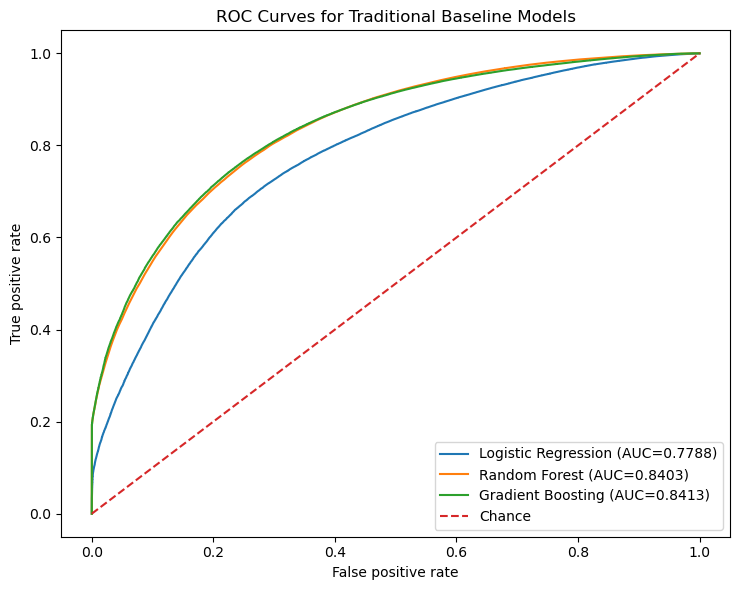

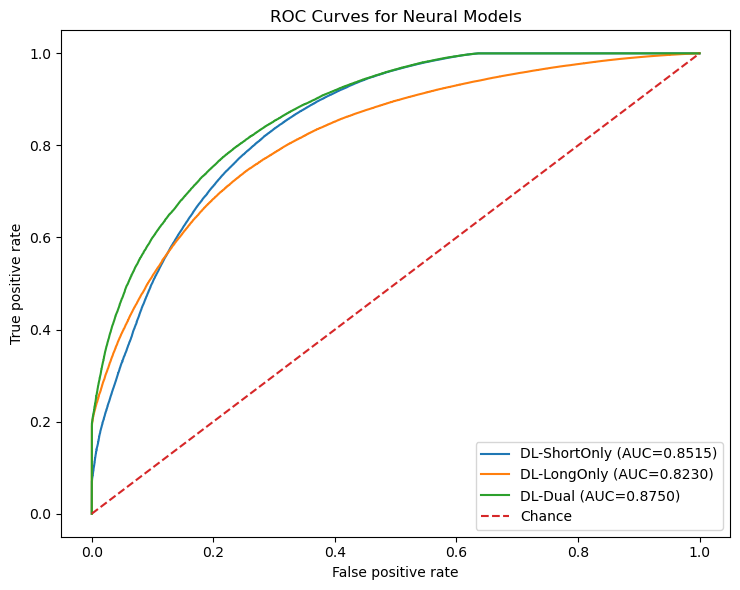

In [18]:
# -----------------------------------------------------------------------------
# PRIMARY ROC CURVES
# Generates ROC figures directly from stored holdout predictions so the plotted
# curves correspond to the numerical primary results reported in the manuscript.
# -----------------------------------------------------------------------------
from sklearn.metrics import roc_curve

def plot_roc_from_store(model_names, store, title, filename):
    plt.figure(figsize=(7.5, 6))

    for model_name in model_names:
        item = store[model_name]
        y_true = np.asarray(item["y_true"])
        probabilities = np.asarray(item["probabilities"])
        fpr, tpr, _ = roc_curve(y_true, probabilities)
        auc_value = roc_auc_score(y_true, probabilities)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_value:.4f})")

    plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_roc_from_store(
    ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    primary_baseline_store,
    "ROC Curves for Traditional Baseline Models",
    "fig5_baseline_roc_curves.png",
)

plot_roc_from_store(
    ["DL-ShortOnly", "DL-LongOnly", "DL-Dual"],
    primary_dl_store,
    "ROC Curves for Neural Models",
    "fig6_neural_roc_curves.png",
)


## 16. Overall primary-model ROC-AUC comparison


,Model,ROC_AUC
0,DL-Dual,0.874980
1,DL-ShortOnly,0.851517
2,Gradient Boosting,0.841307
3,Random Forest,0.840275
4,DL-LongOnly,0.822956
5,Logistic Regression,0.778756


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\all_model_primary_roc_auc_comparison.csv


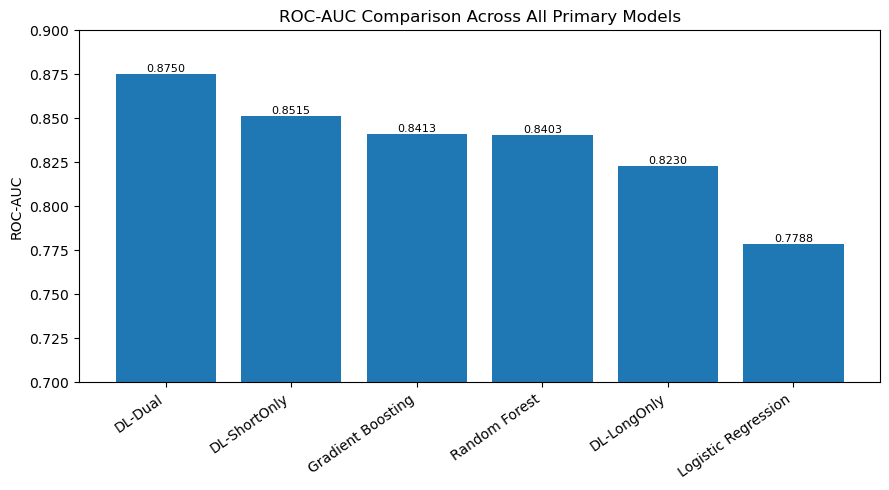

In [19]:
# -----------------------------------------------------------------------------
# CONSOLIDATED HOLDOUT ROC-AUC COMPARISON
# Places all primary baseline and neural models in one comparison table/figure.
# This is a descriptive holdout comparison; statistical testing is performed
# later using matched cross-validation folds.
# -----------------------------------------------------------------------------
all_primary = pd.concat(
    [
        primary_baseline_results[["Model", "ROC_AUC"]],
        primary_dl_results[["Model", "ROC_AUC"]],
    ],
    ignore_index=True,
).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)

display(all_primary)
save_table(all_primary, "all_model_primary_roc_auc_comparison")

plt.figure(figsize=(9, 5))
plt.bar(all_primary["Model"], all_primary["ROC_AUC"])
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Comparison Across All Primary Models")
plt.xticks(rotation=35, ha="right")
plt.ylim(0.70, 0.90)

for i, value in enumerate(all_primary["ROC_AUC"]):
    plt.text(i, value, f"{value:.4f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig8_all_model_roc_auc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


## 17. Ten-fold GroupKFold validation

The validation folds are grouped by `user_id`. Each fold trains on a 75/25 undersampled training partition and evaluates on the untouched validation partition.


In [20]:
# -----------------------------------------------------------------------------
# 10-FOLD GROUPED CROSS-VALIDATION: TRADITIONAL BASELINES
# CHECKPOINT-SAFE VERSION
#
# Scientific procedure is unchanged:
#   * GroupKFold with user_id groups
#   * training-fold-only 75/25 class balancing
#   * same baseline models / hyperparameters / seed
#   * natural validation prevalence
#
# Operational additions only:
#   * prints progress before/after every model
#   * saves each completed model-fold result immediately
#   * resumes completed model-fold combinations after a kernel restart
# -----------------------------------------------------------------------------
from sklearn.model_selection import GroupKFold
from pathlib import Path
import time

baseline_cv_results = pd.DataFrame()

if RUN_BASELINE_CV:

    checkpoint_path = (
        TAB_DIR / "baseline_groupkfold_CHECKPOINT.csv"
    )

    X_all = train_df[long_cols].to_numpy(
        dtype=np.float32
    )

    y_all = train_df["y_order"].to_numpy(
        dtype=np.int64
    )

    groups_all = train_df["user_id"].to_numpy()

    group_kfold = GroupKFold(
        n_splits=CV_FOLDS
    )

    # Recover completed model-fold results after an interrupted run.
    if checkpoint_path.exists():
        checkpoint_df = pd.read_csv(checkpoint_path)

        required_checkpoint_columns = {
            "Fold",
            "Model",
            "Feature_Set",
        }

        if required_checkpoint_columns.issubset(
            checkpoint_df.columns
        ):
            checkpoint_df["Fold"] = (
                checkpoint_df["Fold"].astype(int)
            )

            cv_rows = checkpoint_df.to_dict(
                orient="records"
            )

            completed_pairs = set(
                zip(
                    checkpoint_df["Fold"],
                    checkpoint_df["Model"],
                )
            )

            print(
                f"Recovered {len(checkpoint_df)} completed "
                f"model-fold results from checkpoint."
            )
        else:
            raise ValueError(
                "Baseline CV checkpoint exists but does not "
                "have the expected columns. Remove or rename "
                f"{checkpoint_path} before continuing."
            )
    else:
        cv_rows = []
        completed_pairs = set()
        print("No baseline CV checkpoint found; starting fresh.")

    for fold_number, (
        train_indices,
        validation_indices,
    ) in enumerate(
        group_kfold.split(
            X_all,
            y_all,
            groups=groups_all,
        ),
        start=1,
    ):

        print(
            f"\n===== Baseline fold "
            f"{fold_number}/{CV_FOLDS} ====="
        )

        X_fold_train = X_all[
            train_indices
        ]

        y_fold_train = y_all[
            train_indices
        ]

        groups_fold_train = groups_all[
            train_indices
        ]

        X_fold_validation = X_all[
            validation_indices
        ]

        y_fold_validation = y_all[
            validation_indices
        ]

        fold_train_frame = pd.DataFrame(
            X_fold_train,
            columns=long_cols,
        )

        fold_train_frame["y_order"] = (
            y_fold_train
        )

        fold_train_frame["user_id"] = (
            groups_fold_train
        )

        fold_train_balanced = undersample_to_ratio(
            fold_train_frame,
            target_minority_share=TRAIN_NEGATIVE_SHARE,
            seed=RANDOM_SEED,
        )

        X_balanced = fold_train_balanced[
            long_cols
        ].to_numpy(dtype=np.float32)

        y_balanced = fold_train_balanced[
            "y_order"
        ].to_numpy(dtype=np.int64)

        for (
            model_name,
            estimator_template,
            use_scaling,
        ) in baseline_models:

            pair = (fold_number, model_name)

            if pair in completed_pairs:
                print(
                    f"SKIP | Fold {fold_number}/{CV_FOLDS} | "
                    f"{model_name} already checkpointed"
                )
                continue

            print(
                f"START | Fold {fold_number}/{CV_FOLDS} | "
                f"{model_name}",
                flush=True,
            )

            model_start = time.perf_counter()

            estimator = clone(
                estimator_template
            )

            (
                _,
                _,
                probabilities,
                training_seconds,
                inference_seconds,
            ) = fit_predict_baseline(
                estimator,
                X_balanced,
                y_balanced,
                X_fold_validation,
                scale=use_scaling,
            )

            metrics = evaluate_probabilities(
                y_fold_validation,
                probabilities,
                threshold=FIXED_THRESHOLD,
            )

            metrics["Fold"] = fold_number
            metrics["Model"] = model_name
            metrics["Feature_Set"] = (
                "LongOnly_PRIMARY"
            )

            metrics["Training_Time_s"] = (
                training_seconds
            )
            metrics["Inference_Time_s"] = (
                inference_seconds
            )

            cv_rows.append(metrics)
            completed_pairs.add(pair)

            # Save immediately after every successfully completed model.
            pd.DataFrame(cv_rows).to_csv(
                checkpoint_path,
                index=False,
            )

            elapsed = time.perf_counter() - model_start

            print(
                f"DONE  | Fold {fold_number}/{CV_FOLDS} | "
                f"{model_name} | {elapsed/60:.2f} min | "
                f"checkpoint saved",
                flush=True,
            )

        print(
            f"Completed baseline fold "
            f"{fold_number}/{CV_FOLDS}",
            flush=True,
        )

    baseline_cv_results = (
        pd.DataFrame(cv_rows)
        .sort_values(["Fold", "Model"])
        .reset_index(drop=True)
    )

    # Confirm that every expected model-fold pair is present.
    expected_pairs = {
        (fold, model_name)
        for fold in range(1, CV_FOLDS + 1)
        for model_name, _, _ in baseline_models
    }

    observed_pairs = set(
        zip(
            baseline_cv_results["Fold"].astype(int),
            baseline_cv_results["Model"],
        )
    )

    missing_pairs = expected_pairs - observed_pairs

    if missing_pairs:
        raise RuntimeError(
            "Baseline CV finished without all expected "
            f"model-fold results. Missing: {sorted(missing_pairs)}"
        )

    save_table(
        baseline_cv_results,
        "primary_baseline_groupkfold_fold_metrics",
    )

    baseline_cv_summary = (
        baseline_cv_results.groupby("Model")[
            [
                "ROC_AUC",
                "PR_AUC",
                "Precision",
                "Recall",
                "F1",
                "MCC",
            ]
        ]
        .agg(["mean", "std"])
        .round(6)
    )

    baseline_cv_summary.to_csv(
        TAB_DIR / "primary_baseline_groupkfold_summary.csv"
    )

    display(baseline_cv_summary)

    # The checkpoint is no longer needed after a complete successful run.
    if checkpoint_path.exists():
        checkpoint_path.unlink()
        print(
            "Baseline CV completed successfully; "
            "temporary checkpoint removed."
        )

else:

    print("Baseline GroupKFold CV is disabled.")


No baseline CV checkpoint found; starting fresh.

===== Baseline fold 1/10 =====
START | Fold 1/10 | Logistic Regression
DONE  | Fold 1/10 | Logistic Regression | 0.01 min | checkpoint saved
START | Fold 1/10 | Random Forest
DONE  | Fold 1/10 | Random Forest | 1.95 min | checkpoint saved
START | Fold 1/10 | Gradient Boosting
DONE  | Fold 1/10 | Gradient Boosting | 3.80 min | checkpoint saved
Completed baseline fold 1/10

===== Baseline fold 2/10 =====
START | Fold 2/10 | Logistic Regression
DONE  | Fold 2/10 | Logistic Regression | 0.01 min | checkpoint saved
START | Fold 2/10 | Random Forest
DONE  | Fold 2/10 | Random Forest | 1.90 min | checkpoint saved
START | Fold 2/10 | Gradient Boosting
DONE  | Fold 2/10 | Gradient Boosting | 3.71 min | checkpoint saved
Completed baseline fold 2/10

===== Baseline fold 3/10 =====
START | Fold 3/10 | Logistic Regression
DONE  | Fold 3/10 | Logistic Regression | 0.02 min | checkpoint saved
START | Fold 3/10 | Random Forest
DONE  | Fold 3/10 | Rando

ROC_AUC              PR_AUC           Precision  \
                         mean       std      mean       std      mean   
Model                                                                   
Gradient Boosting    0.841384  0.001581  0.987127  0.000135  0.963332   
Logistic Regression  0.778217  0.001943  0.980042  0.000197  0.973604   
Random Forest        0.839751  0.001300  0.986898  0.000113  0.964051   

                                 Recall                  F1            \
                          std      mean       std      mean       std   
Model                                                                   
Gradient Boosting    0.000261  0.933814  0.001309  0.948343  0.000656   
Logistic Regression  0.000343  0.734261  0.004130  0.837156  0.002653   
Random Forest        0.000146  0.931593  0.001569  0.947543  0.000812   

                          MCC            
                         mean       std  
Model                                    
Gradient Boosting    0.317859  0.003441  
Logistic Regression  0.222363  0.002557  
Random Forest        0.321918  0.003324

Baseline CV completed successfully; temporary checkpoint removed.


In [21]:
# -----------------------------------------------------------------------------
# 10-FOLD GROUPED CROSS-VALIDATION: DUAL-TIMESCALE MODEL
# Evaluates the proposed architecture on the same user-grouped folds used for
# comparison. The reviewer-facing CV configuration uses 5 epochs per fold.
# Fold-level results are retained for paired statistical testing.
# -----------------------------------------------------------------------------
dual_cv_results = pd.DataFrame()

if RUN_DUAL_CV:

    dual_group_kfold = GroupKFold(
        n_splits=CV_FOLDS
    )

    dual_groups = train_df[
        "user_id"
    ].to_numpy()

    dual_fold_rows = []

    for fold_number, (
        train_indices,
        validation_indices,
    ) in enumerate(
        dual_group_kfold.split(
            train_df,
            train_df["y_order"],
            groups=dual_groups,
        ),
        start=1,
    ):

        fold_train_full = train_df.iloc[
            train_indices
        ].copy()

        fold_validation = train_df.iloc[
            validation_indices
        ].copy()

        fold_train_balanced = undersample_to_ratio(
            fold_train_full,
            target_minority_share=TRAIN_NEGATIVE_SHARE,
            seed=RANDOM_SEED + fold_number,
        )

        train_sequences = build_sequences(
            fold_train_balanced,
            max_len=MAIN_T,
        )

        validation_sequences = build_sequences(
            fold_validation,
            max_len=MAIN_T,
        )

        train_loader = DataLoader(
            SeqDataset(train_sequences),
            batch_size=BATCH_SIZE,
            shuffle=True,
            collate_fn=collate_pad,
        )

        validation_loader = DataLoader(
            SeqDataset(validation_sequences),
            batch_size=BATCH_SIZE,
            shuffle=False,
            collate_fn=collate_pad,
        )

        print(
            f"\n[Fold {fold_number:02d}] "
            f"train_bal={len(fold_train_balanced):,} "
            f"validation={len(fold_validation):,}"
        )

        dual_model = Dual(
            len(short_cols),
            len(long_cols),
        )

        dual_model, training_seconds = train_seq_model(
            dual_model,
            train_loader,
            epochs=EPOCHS_CV,
            learning_rate=LR_DL,
        )

        validation_y, validation_probabilities, inference_seconds = (
            predict_seq_probs(
                dual_model,
                validation_loader,
            )
        )

        metrics = evaluate_probabilities(
            validation_y.astype(int),
            validation_probabilities,
            threshold=FIXED_THRESHOLD,
        )

        metrics["Fold"] = fold_number
        metrics["Model"] = "DL-Dual"
        metrics["T"] = MAIN_T
        metrics["Epochs"] = EPOCHS_CV

        metrics["Training_Time_s"] = (
            training_seconds
        )
        metrics["Inference_Time_s"] = (
            inference_seconds
        )

        dual_fold_rows.append(metrics)

        print(
            f"Fold {fold_number:02d} | "
            f"ROC-AUC={metrics['ROC_AUC']:.4f} | "
            f"PR-AUC={metrics['PR_AUC']:.4f} | "
            f"F1={metrics['F1']:.4f} | "
            f"MCC={metrics['MCC']:.4f}"
        )

    dual_cv_results = pd.DataFrame(
        dual_fold_rows
    )

    save_table(
        dual_cv_results,
        "primary_dual_groupkfold_fold_metrics",
    )

    dual_cv_summary = (
        dual_cv_results[
            [
                "ROC_AUC",
                "PR_AUC",
                "Precision",
                "Recall",
                "F1",
                "MCC",
            ]
        ]
        .agg(["mean", "std"])
        .T
        .round(6)
    )

    dual_cv_summary.to_csv(
        TAB_DIR / "primary_dual_groupkfold_summary.csv"
    )

    display(dual_cv_summary)

else:

    print("Dual GroupKFold CV is disabled.")



[Fold 01] train_bal=519,644 validation=239,203
  Epoch 01/5 loss=0.3632
  Epoch 02/5 loss=0.3401
  Epoch 03/5 loss=0.3346
  Epoch 04/5 loss=0.3308
  Epoch 05/5 loss=0.3281
Fold 01 | ROC-AUC=0.8755 | PR-AUC=0.9889 | F1=0.9763 | MCC=0.5503

[Fold 02] train_bal=519,644 validation=239,203
  Epoch 01/5 loss=0.3655
  Epoch 02/5 loss=0.3399
  Epoch 03/5 loss=0.3346
  Epoch 04/5 loss=0.3302
  Epoch 05/5 loss=0.3274
Fold 02 | ROC-AUC=0.8748 | PR-AUC=0.9888 | F1=0.9767 | MCC=0.5555

[Fold 03] train_bal=519,644 validation=239,203
  Epoch 01/5 loss=0.3655
  Epoch 02/5 loss=0.3387
  Epoch 03/5 loss=0.3324
  Epoch 04/5 loss=0.3279
  Epoch 05/5 loss=0.3261
Fold 03 | ROC-AUC=0.8717 | PR-AUC=0.9886 | F1=0.9772 | MCC=0.5609

[Fold 04] train_bal=519,644 validation=239,203
  Epoch 01/5 loss=0.3615
  Epoch 02/5 loss=0.3375
  Epoch 03/5 loss=0.3321
  Epoch 04/5 loss=0.3284
  Epoch 05/5 loss=0.3268
Fold 04 | ROC-AUC=0.8699 | PR-AUC=0.9884 | F1=0.9785 | MCC=0.5897

[Fold 05] train_bal=519,644 validation=239,

,mean,std
ROC_AUC,0.870986,0.003359
PR_AUC,0.988473,0.000360
Precision,0.958995,0.001050
Recall,0.997412,0.002885
F1,0.977823,0.000860
MCC,0.575362,0.016114


## 18. Statistical significance testing

The statistical comparison uses matched fold-wise ROC-AUC values from the Dual-Timescale model and the strongest traditional baseline.

- Test: paired t-test
- Comparison metric: ROC-AUC
- Folds: 10 matched GroupKFold folds
- Bootstrap: 2,000 resamples of the fold-wise ROC-AUC differences
- Bootstrap seed: 42
- Confidence interval: percentile 95% CI


In [22]:
# -----------------------------------------------------------------------------
# PAIRED STATISTICAL COMPARISON
# Matches Dual-Timescale and Gradient Boosting ROC-AUC values by CV fold, applies
# a paired t-test, and bootstraps the mean fold-wise difference to obtain a 95%
# confidence interval. The analysis tests the primary discrimination metric.
# -----------------------------------------------------------------------------
from scipy.stats import ttest_rel

statistical_results = pd.DataFrame()

if (
    not baseline_cv_results.empty
    and not dual_cv_results.empty
):

    baseline_means = (
        baseline_cv_results.groupby(
            "Model"
        )["ROC_AUC"]
        .mean()
        .sort_values(
            ascending=False
        )
    )

    best_baseline_name = (
        baseline_means.index[0]
    )

    best_baseline_auc = (
        baseline_cv_results[
            baseline_cv_results["Model"]
            == best_baseline_name
        ]
        .sort_values("Fold")[
            "ROC_AUC"
        ]
        .to_numpy()
    )

    dual_auc = (
        dual_cv_results
        .sort_values("Fold")[
            "ROC_AUC"
        ]
        .to_numpy()
    )

    number_folds = min(
        len(best_baseline_auc),
        len(dual_auc),
    )

    best_baseline_auc = (
        best_baseline_auc[
            :number_folds
        ]
    )

    dual_auc = (
        dual_auc[
            :number_folds
        ]
    )

    auc_difference = (
        dual_auc
        - best_baseline_auc
    )

    t_statistic, p_value = ttest_rel(
        dual_auc,
        best_baseline_auc,
    )

    bootstrap_rng = np.random.default_rng(
        RANDOM_SEED
    )

    bootstrap_iterations = BOOTSTRAP_ITERATIONS

    bootstrap_means = []

    for _ in range(
        bootstrap_iterations
    ):

        sampled_indices = (
            bootstrap_rng.integers(
                0,
                number_folds,
                size=number_folds,
            )
        )

        bootstrap_means.append(
            auc_difference[
                sampled_indices
            ].mean()
        )

    ci_lower = np.percentile(
        bootstrap_means,
        2.5,
    )

    ci_upper = np.percentile(
        bootstrap_means,
        97.5,
    )

    statistical_results = pd.DataFrame(
        [
            {
                "Best_Original_Baseline": best_baseline_name,
                "Number_of_Folds": number_folds,
                "Mean_Dual_ROC_AUC": dual_auc.mean(),
                "Mean_Baseline_ROC_AUC": best_baseline_auc.mean(),
                "Mean_ROC_AUC_Difference": auc_difference.mean(),
                "Paired_t": t_statistic,
                "p_value": p_value,
                "Bootstrap_95CI_Lower": ci_lower,
                "Bootstrap_95CI_Upper": ci_upper,
                "Bootstrap_Iterations": bootstrap_iterations,
            }
        ]
    )

    save_table(
        statistical_results,
        "primary_dual_vs_best_original_baseline_statistics",
    )

    display(
        baseline_means.rename(
            "Mean_ROC_AUC"
        ).reset_index()
    )

    display(statistical_results)

else:

    print(
        "Statistical comparison skipped because "
        "baseline and/or Dual CV is unavailable."
    )


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\primary_dual_vs_best_original_baseline_statistics.csv


,Model,Mean_ROC_AUC
0,Gradient Boosting,0.841384
1,Random Forest,0.839751
2,Logistic Regression,0.778217


,Best_Original_Baseline,Number_of_Folds,Mean_Dual_ROC_AUC,Mean_Baseline_ROC_AUC,Mean_ROC_AUC_Difference,Paired_t,p_value,Bootstrap_95CI_Lower,Bootstrap_95CI_Upper,Bootstrap_Iterations
0,Gradient Boosting,10,0.870986,0.841384,0.029601,32.174556,1.330079e-10,0.027901,0.031372,2000


## 19. SHAP explainability for the strongest traditional baseline

SHAP is applied to the fitted Gradient Boosting baseline using the engineered long-term behavioural features. It is not presented as a direct explanation of the LSTM hidden state or the complete fusion model.


C:\Users\t_jaf\AppData\Local\Temp\ipykernel_21180\3662651694.py:121: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


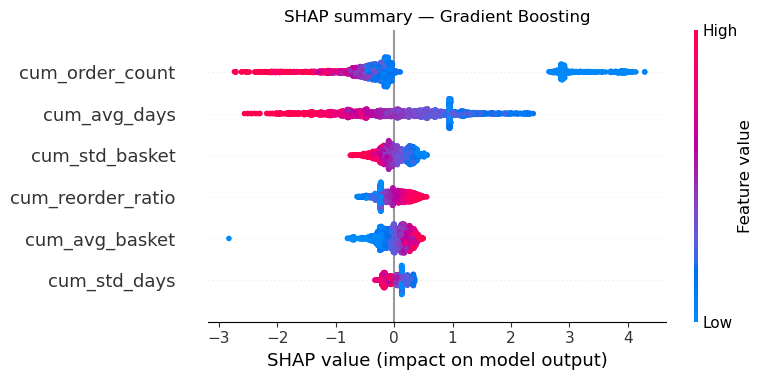

Interpretability limitation: this SHAP analysis explains engineered long-term tabular features, not the LSTM's internal sequential representations.


In [23]:
# -----------------------------------------------------------------------------
# SHAP EXPLAINABILITY — GRADIENT BOOSTING BASELINE
# SHAP is intentionally applied to the fitted Gradient Boosting baseline and the
# engineered long-term behavioural features. It provides feature-level evidence
# for these variables; it does NOT explain the internal LSTM/fusion states of the
# Dual-Timescale neural network.
# -----------------------------------------------------------------------------
if RUN_SHAP:

    try:
        import shap

    except ImportError:
        shap = None
        print(
            "SHAP is not installed. "
            "Install it with: pip install shap"
        )

    if shap is not None:

        best_baseline_name = (
            primary_baseline_results
            .sort_values(
                "ROC_AUC",
                ascending=False,
            )
            .iloc[0]["Model"]
        )

        fitted_baseline = (
            primary_baseline_store[
                best_baseline_name
            ]["model"]
        )

        fitted_scaler = (
            primary_baseline_store[
                best_baseline_name
            ]["scaler"]
        )

        shap_test_matrix = (
            test_df[long_cols]
            .to_numpy(dtype=np.float32)
        )

        shap_sample_size = min(
            2000,
            len(shap_test_matrix),
        )

        shap_indices = np.random.choice(
            np.arange(
                len(shap_test_matrix)
            ),
            size=shap_sample_size,
            replace=False,
        )

        shap_sample = (
            shap_test_matrix[
                shap_indices
            ]
        )

        if fitted_scaler is not None:
            shap_model_input = (
                fitted_scaler.transform(
                    shap_sample
                )
            )

        else:
            shap_model_input = (
                shap_sample
            )

        try:

            explainer = shap.TreeExplainer(
                fitted_baseline
            )

            shap_values = (
                explainer.shap_values(
                    shap_model_input
                )
            )

            if isinstance(
                shap_values,
                list,
            ):
                shap_values_to_plot = (
                    shap_values[1]
                )

            else:
                shap_values_to_plot = (
                    shap_values
                )

        except Exception:

            explainer = shap.Explainer(
                fitted_baseline,
                shap_model_input,
            )

            shap_explanation = (
                explainer(
                    shap_model_input
                )
            )

            shap_values_to_plot = (
                shap_explanation.values
            )

        shap.summary_plot(
            shap_values_to_plot,
            features=shap_model_input,
            feature_names=long_cols,
            show=False,
        )

        plt.title(
            f"SHAP summary — "
            f"{best_baseline_name}"
        )

        plt.tight_layout()

        plt.savefig(
            FIG_DIR / "shap_long_term_best_baseline.png",
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()

        print(
            "Interpretability limitation: this SHAP analysis "
            "explains engineered long-term tabular features, "
            "not the LSTM's internal sequential representations."
        )

else:

    print("SHAP analysis is disabled.")


## 20. Hyperparameter and implementation summary


In [24]:
# -----------------------------------------------------------------------------
# HYPERPARAMETER / IMPLEMENTATION SUMMARY
# Creates a machine-readable table of the key split, architecture, optimisation,
# sequence-length, CV, threshold, and random-seed settings used in the study.
# -----------------------------------------------------------------------------
hyperparameter_table = pd.DataFrame(
    [
        {
            "Component": "Data split",
            "Parameter": "Holdout test proportion",
            "Value": TEST_SIZE,
        },
        {
            "Component": "Data split",
            "Parameter": "Grouping unit",
            "Value": "user_id",
        },
        {
            "Component": "Training balance",
            "Parameter": "Negative share after undersampling",
            "Value": TRAIN_NEGATIVE_SHARE,
        },
        {
            "Component": "Short-term sequence",
            "Parameter": "Primary T",
            "Value": MAIN_T,
        },
        {
            "Component": "Short-term sequence",
            "Parameter": "Supplementary T values",
            "Value": str(T_SENSITIVITY_VALUES),
        },
        {
            "Component": "LSTM",
            "Parameter": "Hidden units",
            "Value": 64,
        },
        {
            "Component": "LSTM",
            "Parameter": "Number of layers",
            "Value": 1,
        },
        {
            "Component": "Long FCNN",
            "Parameter": "Hidden units",
            "Value": 64,
        },
        {
            "Component": "Long FCNN",
            "Parameter": "Activation",
            "Value": "ReLU",
        },
        {
            "Component": "Neural",
            "Parameter": "Dropout",
            "Value": 0.2,
        },
        {
            "Component": "Fusion",
            "Parameter": "Hidden units",
            "Value": 64,
        },
        {
            "Component": "Neural",
            "Parameter": "Optimizer",
            "Value": "Adam",
        },
        {
            "Component": "Neural",
            "Parameter": "Learning rate",
            "Value": LR_DL,
        },
        {
            "Component": "Neural",
            "Parameter": "Batch size",
            "Value": BATCH_SIZE,
        },
        {
            "Component": "Neural",
            "Parameter": "Holdout epochs",
            "Value": EPOCHS_HOLDOUT,
        },
        {
            "Component": "Neural CV",
            "Parameter": "Epochs per fold",
            "Value": EPOCHS_CV,
        },
        {
            "Component": "Evaluation",
            "Parameter": "Classification threshold",
            "Value": FIXED_THRESHOLD,
        },
        {
            "Component": "Cross-validation",
            "Parameter": "Folds",
            "Value": CV_FOLDS,
        },
        {
            "Component": "Randomness",
            "Parameter": "NumPy seed",
            "Value": RANDOM_SEED,
        },
        {
            "Component": "Randomness",
            "Parameter": "PyTorch seed",
            "Value": RANDOM_SEED,
        },
        {
            "Component": "Original sampler audit",
            "Parameter": "Legacy sequence label",
            "Value": "last y_order in retained sequence (audit only)",
        },
        {
            "Component": "Corrected imbalance robustness",
            "Parameter": "Method",
            "Value": "order/time-step class-weighted masked BCE",
        },
        {
            "Component": "Corrected imbalance robustness",
            "Parameter": "Class-weight formula",
            "Value": "N / (2 * N_class)",
        },
        {
            "Component": "Corrected imbalance robustness",
            "Parameter": "Sequence oversampling",
            "Value": False,
        },
        {
            "Component": "Logistic Regression",
            "Parameter": "max_iter",
            "Value": 500,
        },
        {
            "Component": "Logistic Regression",
            "Parameter": "class_weight",
            "Value": "balanced",
        },
        {
            "Component": "Random Forest",
            "Parameter": "n_estimators",
            "Value": 250,
        },
        {
            "Component": "Random Forest",
            "Parameter": "class_weight",
            "Value": "balanced_subsample",
        },
        {
            "Component": "Gradient Boosting",
            "Parameter": "n_estimators",
            "Value": 300,
        },
        {
            "Component": "Gradient Boosting",
            "Parameter": "learning_rate",
            "Value": 0.05,
        },
        {
            "Component": "Gradient Boosting",
            "Parameter": "max_depth",
            "Value": 3,
        },
        {
            "Component": "Gradient Boosting",
            "Parameter": "subsample",
            "Value": 0.8,
        },
    ]
)

save_table(
    hyperparameter_table,
    "hyperparameter_configuration",
)

display(hyperparameter_table)


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\hyperparameter_configuration.csv


,Component,Parameter,Value
0,Data split,Holdout test proportion,0.3
1,Data split,Grouping unit,user_id
2,Training balance,Negative share after undersampling,0.25
3,Short-term sequence,Primary T,50
4,Short-term sequence,Supplementary T values,"[5, 10, 20, 30, 50]"
5,LSTM,Hidden units,64
6,LSTM,Number of layers,1
7,Long FCNN,Hidden units,64
8,Long FCNN,Activation,ReLU
9,Neural,Dropout,0.2


# Reviewer-requested checks and supplementary analyses

The primary experiment above remains unchanged. The sections below document additional checks requested during review and are kept separate from the main experiment so the distinction is clear.


## R1. Exact long-term feature correlations


## R2. Sequence-length sensitivity

This is a retrospective internal-validation analysis for `T ∈ {5, 10, 20, 30, 50}`. It does not retune the primary holdout experiment.


In [25]:
# -----------------------------------------------------------------------------
# R2 — RETROSPECTIVE SEQUENCE-LENGTH SENSITIVITY
# Re-runs Short-only and Dual models for T in {5,10,20,30,50} on the internal
# validation partition. This analysis assesses sensitivity to T; it is NOT used
# to select a new final model or to retune the locked holdout result.
# -----------------------------------------------------------------------------
t_sensitivity_results = pd.DataFrame()

if RUN_T_SENSITIVITY:

    sensitivity_rows = []

    for t_value in T_SENSITIVITY_VALUES:

        print(
            f"\n===== SUPPLEMENTARY T sensitivity: T={t_value} ====="
        )

        t_train_sequences = build_sequences(
            df_tr_in,
            max_len=t_value,
        )

        t_validation_sequences = build_sequences(
            df_val_in,
            max_len=t_value,
        )

        t_train_loader = DataLoader(
            SeqDataset(t_train_sequences),
            batch_size=BATCH_SIZE,
            shuffle=True,
            collate_fn=collate_pad,
        )

        t_validation_loader = DataLoader(
            SeqDataset(
                t_validation_sequences
            ),
            batch_size=BATCH_SIZE,
            shuffle=False,
            collate_fn=collate_pad,
        )

        for model_name, model in [
            (
                "DL-ShortOnly",
                ShortOnly(len(short_cols)),
            ),
            (
                "DL-Dual",
                Dual(
                    len(short_cols),
                    len(long_cols),
                ),
            ),
        ]:

            print(
                f"Training {model_name} at T={t_value}"
            )

            fitted_model, training_seconds = train_seq_model(
                model,
                t_train_loader,
                epochs=EPOCHS_HOLDOUT,
                learning_rate=LR_DL,
            )

            validation_y, validation_probabilities, inference_seconds = (
                predict_seq_probs(
                    fitted_model,
                    t_validation_loader,
                )
            )

            metrics = evaluate_probabilities(
                validation_y.astype(int),
                validation_probabilities,
                threshold=FIXED_THRESHOLD,
            )

            metrics["Model"] = model_name
            metrics["T"] = t_value
            metrics["Dataset"] = (
                "internal_validation_only"
            )

            metrics["Training_Time_s"] = (
                training_seconds
            )
            metrics["Inference_Time_s"] = (
                inference_seconds
            )

            sensitivity_rows.append(metrics)

            print(
                f"  validation ROC-AUC="
                f"{metrics['ROC_AUC']:.4f}, "
                f"PR-AUC={metrics['PR_AUC']:.4f}, "
                f"MCC={metrics['MCC']:.4f}"
            )

    t_sensitivity_results = pd.DataFrame(
        sensitivity_rows
    )

    save_table(
        t_sensitivity_results,
        "supplementary_T_sensitivity_internal_validation",
    )

    display(t_sensitivity_results)

    print(
        "\nIMPORTANT: MAIN_T remains fixed at",
        MAIN_T,
        "for the primary experiment."
    )

else:

    print("T sensitivity analysis is disabled.")



===== SUPPLEMENTARY T sensitivity: T=5 =====
Training DL-ShortOnly at T=5
  Epoch 01/10 loss=0.3776
  Epoch 02/10 loss=0.3433
  Epoch 03/10 loss=0.3405
  Epoch 04/10 loss=0.3394
  Epoch 05/10 loss=0.3386
  Epoch 06/10 loss=0.3382
  Epoch 07/10 loss=0.3374
  Epoch 08/10 loss=0.3371
  Epoch 09/10 loss=0.3368
  Epoch 10/10 loss=0.3365
  validation ROC-AUC=0.8879, PR-AUC=0.9305, MCC=0.6590
Training DL-Dual at T=5
  Epoch 01/10 loss=0.3409
  Epoch 02/10 loss=0.3015
  Epoch 03/10 loss=0.2974
  Epoch 04/10 loss=0.2950
  Epoch 05/10 loss=0.2935
  Epoch 06/10 loss=0.2926
  Epoch 07/10 loss=0.2918
  Epoch 08/10 loss=0.2907
  Epoch 09/10 loss=0.2904
  Epoch 10/10 loss=0.2901
  validation ROC-AUC=0.9257, PR-AUC=0.9607, MCC=0.6793

===== SUPPLEMENTARY T sensitivity: T=10 =====
Training DL-ShortOnly at T=10
  Epoch 01/10 loss=0.4015
  Epoch 02/10 loss=0.3708
  Epoch 03/10 loss=0.3668
  Epoch 04/10 loss=0.3659
  Epoch 05/10 loss=0.3650
  Epoch 06/10 loss=0.3646
  Epoch 07/10 loss=0.3639
  Epoch 08/1

,ROC_AUC,PR_AUC,Average_Precision,Precision,Recall,F1,MCC,Threshold,Model,T,Dataset,Training_Time_s,Inference_Time_s
0,0.887938,0.930524,0.930525,0.834737,0.973781,0.898914,0.658965,0.5,DL-ShortOnly,5,internal_validation_only,218.310252,1.324545
1,0.925704,0.960700,0.960701,0.842263,0.976154,0.904279,0.679335,0.5,DL-Dual,5,internal_validation_only,328.089491,1.630877
2,0.851882,0.929897,0.929898,0.834961,0.982461,0.902726,0.579896,0.5,DL-ShortOnly,10,internal_validation_only,283.532556,1.490205
3,0.887524,0.952420,0.952421,0.822320,0.999784,0.902410,0.580560,0.5,DL-Dual,10,internal_validation_only,439.029225,1.756284
4,0.837751,0.928719,0.928719,0.840403,0.974741,0.902601,0.541892,0.5,DL-ShortOnly,20,internal_validation_only,350.554133,1.801859
5,0.868862,0.947898,0.947899,0.824048,0.999954,0.903519,0.546248,0.5,DL-Dual,20,internal_validation_only,596.254765,2.243301
6,0.837144,0.928807,0.928807,0.834062,0.987735,0.904417,0.546363,0.5,DL-ShortOnly,30,internal_validation_only,388.519965,1.877265
7,0.877887,0.952258,0.952258,0.831773,0.994709,0.905974,0.556286,0.5,DL-Dual,30,internal_validation_only,645.096755,2.204045
8,0.836699,0.928213,0.928214,0.838429,0.980832,0.904057,0.545469,0.5,DL-ShortOnly,50,internal_validation_only,174.260692,0.759747
9,0.874826,0.951084,0.951085,0.826607,0.998882,0.904616,0.549419,0.5,DL-Dual,50,internal_validation_only,256.690531,0.879296



IMPORTANT: MAIN_T remains fixed at 50 for the primary experiment.


,ROC_AUC,PR_AUC,Average_Precision,Precision,Recall,F1,MCC,Threshold,Model,T,Dataset,Training_Time_s,Inference_Time_s
0,0.887938,0.930524,0.930525,0.834737,0.973781,0.898914,0.658965,0.5,DL-ShortOnly,5,internal_validation_only,218.310252,1.324545
1,0.925704,0.960700,0.960701,0.842263,0.976154,0.904279,0.679335,0.5,DL-Dual,5,internal_validation_only,328.089491,1.630877
2,0.851882,0.929897,0.929898,0.834961,0.982461,0.902726,0.579896,0.5,DL-ShortOnly,10,internal_validation_only,283.532556,1.490205
3,0.887524,0.952420,0.952421,0.822320,0.999784,0.902410,0.580560,0.5,DL-Dual,10,internal_validation_only,439.029225,1.756284
4,0.837751,0.928719,0.928719,0.840403,0.974741,0.902601,0.541892,0.5,DL-ShortOnly,20,internal_validation_only,350.554133,1.801859
5,0.868862,0.947898,0.947899,0.824048,0.999954,0.903519,0.546248,0.5,DL-Dual,20,internal_validation_only,596.254765,2.243301
6,0.837144,0.928807,0.928807,0.834062,0.987735,0.904417,0.546363,0.5,DL-ShortOnly,30,internal_validation_only,388.519965,1.877265
7,0.877887,0.952258,0.952258,0.831773,0.994709,0.905974,0.556286,0.5,DL-Dual,30,internal_validation_only,645.096755,2.204045
8,0.836699,0.928213,0.928214,0.838429,0.980832,0.904057,0.545469,0.5,DL-ShortOnly,50,internal_validation_only,174.260692,0.759747
9,0.874826,0.951084,0.951085,0.826607,0.998882,0.904616,0.549419,0.5,DL-Dual,50,internal_validation_only,256.690531,0.879296


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\posthoc_T_sensitivity_full.csv


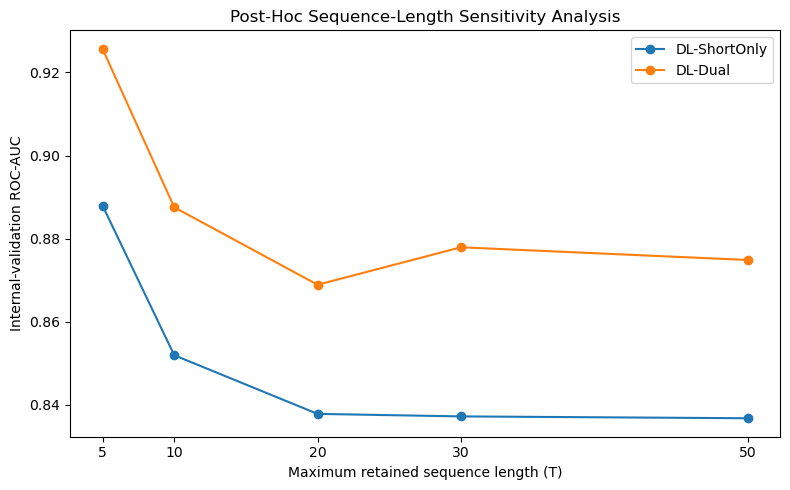

NOTE: T-sensitivity is post-hoc/internal-validation only. It was not used to retune the primary T=50 holdout experiment.


In [26]:
# -----------------------------------------------------------------------------
# R2 — SAVE / VISUALISE T-SENSITIVITY RESULTS
# Exports the sensitivity table and plots performance across T values. Primary
# T=50 holdout results remain unchanged regardless of this post-hoc analysis.
# -----------------------------------------------------------------------------
if not t_sensitivity_results.empty:
    display(t_sensitivity_results)
    save_table(t_sensitivity_results, "posthoc_T_sensitivity_full")

    plt.figure(figsize=(8, 5))

    for model_name in ["DL-ShortOnly", "DL-Dual"]:
        subset = t_sensitivity_results[
            t_sensitivity_results["Model"] == model_name
        ].sort_values("T")

        plt.plot(
            subset["T"],
            subset["ROC_AUC"],
            marker="o",
            label=model_name,
        )

    plt.xlabel("Maximum retained sequence length (T)")
    plt.ylabel("Internal-validation ROC-AUC")
    plt.title("Post-Hoc Sequence-Length Sensitivity Analysis")
    plt.xticks(sorted(t_sensitivity_results["T"].unique()))
    plt.legend(loc="best")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "supplementary_T_sensitivity_roc_auc.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(
        "NOTE: T-sensitivity is post-hoc/internal-validation only. "
        "It was not used to retune the primary T=50 holdout experiment."
    )


## R3. Class-imbalance robustness

The old sequence-level sampler is audited first. The corrected supplementary analysis uses order-level class-weighted masked BCE without resampling the customer sequences.


In [27]:
# -----------------------------------------------------------------------------
# R3 — CLASS-IMBALANCE ROBUSTNESS AND LEGACY-SAMPLER AUDIT
# First audits the earlier sequence-level sampling idea. Because a complete
# customer's final order always has y=0, assigning one class from the final order
# cannot genuinely balance complete customer sequences. The corrected robustness
# experiment therefore keeps sequences intact and applies class weighting to
# order/time-step labels, where the prediction target is actually defined.
# This supplementary experiment does not replace the primary 75/25 undersampling.
# -----------------------------------------------------------------------------
original_sampler_audit = pd.DataFrame()
corrected_imbalance_results = pd.DataFrame()
corrected_imbalance_store = {}

if RUN_ORIGINAL_SAMPLER_AUDIT:

    audit_train_sequences = build_sequences(
        df_tr_in,
        max_len=MAIN_T,
    )

    audit_sequence_labels = np.array(
        [
            int(sequence[2][-1])
            for sequence in audit_train_sequences
        ],
        dtype=int,
    )

    audit_sequence_counts = np.bincount(
        audit_sequence_labels,
        minlength=2,
    )

    original_sampler_audit = pd.DataFrame(
        [
            {
                "sequence_class": class_index,
                "sequence_count": int(audit_sequence_counts[class_index]),
                "proportion": float(
                    audit_sequence_counts[class_index]
                    / max(audit_sequence_counts.sum(), 1)
                ),
            }
            for class_index in range(2)
        ]
    )

    sampler_has_two_classes = bool(
        (audit_sequence_counts > 0).all()
    )

    original_sampler_audit["valid_for_class_balancing"] = sampler_has_two_classes

    save_table(
        original_sampler_audit,
        "original_weighted_random_sampler_audit",
    )
    display(original_sampler_audit)

    if not sampler_has_two_classes:
        print(
            "AUDIT RESULT: the original sequence-level sampler labels are degenerate "
            "(at least one class has zero sequences). WeightedRandomSampler is therefore "
            "NOT used as evidence of class balancing in this revised analysis."
        )
    else:
        print(
            "AUDIT RESULT: both sequence-level sampler classes are present. "
            "The original method is documented for reproducibility, but the corrected "
            "order-level weighted-loss analysis below remains the preferred robustness check."
        )

else:
    print("Original sampler audit is disabled.")

def weighted_masked_bce(
    probabilities,
    labels,
    mask,
    negative_weight,
    positive_weight,
):

    epsilon = 1e-7
    probabilities = torch.clamp(
        probabilities,
        epsilon,
        1 - epsilon,
    )

    element_loss = bce(
        probabilities,
        labels,
    )

    class_weight_tensor = torch.where(
        labels >= 0.5,
        torch.as_tensor(
            positive_weight,
            dtype=element_loss.dtype,
            device=element_loss.device,
        ),
        torch.as_tensor(
            negative_weight,
            dtype=element_loss.dtype,
            device=element_loss.device,
        ),
    )

    weighted_loss = (
        element_loss
        * class_weight_tensor
        * mask
    )

    return weighted_loss.sum() / mask.sum()

def train_seq_model_weighted_loss(
    model,
    train_loader,
    epochs,
    learning_rate,
    negative_weight,
    positive_weight,
):

    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    if device.type == "cuda":
        torch.cuda.synchronize()

    training_start = time.perf_counter()

    for epoch in range(1, epochs + 1):

        model.train()

        total_loss = 0.0

        for short_x, long_x, labels, mask in train_loader:

            short_x = short_x.to(device)
            long_x = long_x.to(device)
            labels = labels.to(device)
            mask = mask.to(device)

            optimizer.zero_grad()

            if isinstance(model, ShortOnly):
                probabilities = model(short_x)
            elif isinstance(model, LongOnly):
                probabilities = model(long_x)
            else:
                probabilities = model(short_x, long_x)

            loss = weighted_masked_bce(
                probabilities,
                labels,
                mask,
                negative_weight=negative_weight,
                positive_weight=positive_weight,
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(
            f"  Epoch {epoch:02d}/{epochs} "
            f"weighted_loss={total_loss / len(train_loader):.4f}"
        )

    if device.type == "cuda":
        torch.cuda.synchronize()

    training_seconds = time.perf_counter() - training_start

    return model, training_seconds

if RUN_CORRECTED_IMBALANCE_ROBUSTNESS:

    print(
        "\n===== CORRECTED SUPPLEMENTARY IMBALANCE ROBUSTNESS: "
        "order-level class-weighted masked BCE ====="
    )

    robustness_train_sequences = build_sequences(
        df_tr_in,
        max_len=MAIN_T,
    )
    robustness_validation_sequences = build_sequences(
        df_val_in,
        max_len=MAIN_T,
    )
    robustness_test_sequences = build_sequences(
        df_test,
        max_len=MAIN_T,
    )

    robustness_train_labels = np.concatenate(
        [sequence[2] for sequence in robustness_train_sequences]
    ).astype(int)

    order_class_counts = np.bincount(
        robustness_train_labels,
        minlength=2,
    )

    if (order_class_counts == 0).any():
        raise ValueError(
            "Corrected weighted-loss robustness analysis cannot run because "
            "one order/time-step class has zero observations."
        )

    total_order_labels = int(order_class_counts.sum())
    negative_weight = total_order_labels / (2.0 * order_class_counts[0])
    positive_weight = total_order_labels / (2.0 * order_class_counts[1])

    corrected_weight_table = pd.DataFrame(
        [
            {
                "order_class": 0,
                "order_count": int(order_class_counts[0]),
                "proportion": float(order_class_counts[0] / total_order_labels),
                "loss_weight": float(negative_weight),
            },
            {
                "order_class": 1,
                "order_count": int(order_class_counts[1]),
                "proportion": float(order_class_counts[1] / total_order_labels),
                "loss_weight": float(positive_weight),
            },
        ]
    )

    save_table(
        corrected_weight_table,
        "corrected_order_level_class_weights",
    )
    display(corrected_weight_table)

    robustness_train_loader = DataLoader(
        SeqDataset(robustness_train_sequences),
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=collate_pad,
    )

    robustness_validation_loader = DataLoader(
        SeqDataset(robustness_validation_sequences),
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_pad,
    )
    robustness_test_loader = DataLoader(
        SeqDataset(robustness_test_sequences),
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_pad,
    )

    torch.manual_seed(RANDOM_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_SEED)

    robustness_models = [
        (
            "DL-ShortOnly",
            ShortOnly(len(short_cols)),
        ),
        (
            "DL-LongOnly",
            LongOnly(len(long_cols)),
        ),
        (
            "DL-Dual",
            Dual(
                len(short_cols),
                len(long_cols),
            ),
        ),
    ]

    robustness_rows = []

    for model_name, model in robustness_models:

        print("Training corrected robustness model:", model_name)

        parameter_count = count_trainable_parameters(model)

        fitted_model, training_seconds = train_seq_model_weighted_loss(
            model,
            robustness_train_loader,
            epochs=EPOCHS_HOLDOUT,
            learning_rate=LR_DL,
            negative_weight=negative_weight,
            positive_weight=positive_weight,
        )

        validation_y, validation_probabilities, _ = predict_seq_probs(
            fitted_model,
            robustness_validation_loader,
        )
        validation_f1 = f1_score(
            validation_y.astype(int),
            (validation_probabilities >= FIXED_THRESHOLD).astype(int),
            zero_division=0,
        )

        test_y, test_probabilities, inference_seconds = predict_seq_probs(
            fitted_model,
            robustness_test_loader,
        )

        metrics = evaluate_probabilities(
            test_y.astype(int),
            test_probabilities,
            threshold=FIXED_THRESHOLD,
        )

        metrics["Model"] = model_name
        metrics["Training_Regime"] = "Order-level class-weighted masked BCE"
        metrics["T"] = MAIN_T
        metrics["Val_F1_at_0.5"] = validation_f1
        metrics["Trainable_Parameters"] = parameter_count
        metrics["Training_Time_s"] = training_seconds
        metrics["Inference_Time_s"] = inference_seconds
        metrics["Inference_ms_per_Order"] = (
            1000.0 * inference_seconds / len(test_y)
        )

        robustness_rows.append(metrics)

        corrected_imbalance_store[model_name] = {
            "model": fitted_model,
            "y_true": test_y.astype(int),
            "probabilities": test_probabilities,
        }

        print(
            f"  {model_name}: "
            f"ROC-AUC={metrics['ROC_AUC']:.4f}, "
            f"PR-AUC={metrics['PR_AUC']:.4f}, "
            f"F1={metrics['F1']:.4f}, "
            f"MCC={metrics['MCC']:.4f}"
        )

    corrected_imbalance_results = pd.DataFrame(
        robustness_rows
    ).sort_values(
        "ROC_AUC",
        ascending=False,
    ).reset_index(drop=True)

    save_table(
        corrected_imbalance_results,
        "corrected_order_level_weighted_loss_robustness",
    )
    display(corrected_imbalance_results)

    primary_dual_row = primary_dl_results[
        primary_dl_results["Model"] == "DL-Dual"
    ].iloc[0]

    corrected_dual_row = corrected_imbalance_results[
        corrected_imbalance_results["Model"] == "DL-Dual"
    ].iloc[0]

    robustness_comparison = pd.DataFrame(
        [
            {
                "Experiment": "PRIMARY",
                "Training_Regime": "Original masked BCE",
                "ROC_AUC": float(primary_dual_row["ROC_AUC"]),
                "PR_AUC": float(primary_dual_row["PR_AUC"]),
                "F1": float(primary_dual_row["F1"]),
                "MCC": float(primary_dual_row["MCC"]),
            },
            {
                "Experiment": "SUPPLEMENTARY_ROBUSTNESS",
                "Training_Regime": "Order-level class-weighted masked BCE",
                "ROC_AUC": float(corrected_dual_row["ROC_AUC"]),
                "PR_AUC": float(corrected_dual_row["PR_AUC"]),
                "F1": float(corrected_dual_row["F1"]),
                "MCC": float(corrected_dual_row["MCC"]),
            },
        ]
    )

    robustness_comparison["ROC_AUC_Difference_vs_Primary"] = (
        robustness_comparison["ROC_AUC"]
        - float(primary_dual_row["ROC_AUC"])
    )

    save_table(
        robustness_comparison,
        "primary_vs_corrected_imbalance_robustness_dual",
    )
    display(robustness_comparison)

    print(
        "IMPORTANT: Section 14 remains the PRIMARY experiment. "
        "This weighted-loss run is supplementary reviewer evidence only."
    )

else:
    print("Corrected imbalance robustness analysis is disabled.")


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\original_weighted_random_sampler_audit.csv


,sequence_class,sequence_count,proportion,valid_for_class_balancing
0,0,115476,1.0,False
1,1,0,0.0,False


AUDIT RESULT: the original sequence-level sampler labels are degenerate (at least one class has zero sequences). WeightedRandomSampler is therefore NOT used as evidence of class balancing in this revised analysis.

===== CORRECTED SUPPLEMENTARY IMBALANCE ROBUSTNESS: order-level class-weighted masked BCE =====
[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\corrected_order_level_class_weights.csv


,order_class,order_count,proportion,loss_weight
0,0,115476,0.250082,1.999346
1,1,346277,0.749918,0.666739


Training corrected robustness model: DL-ShortOnly
  Epoch 01/10 weighted_loss=0.4997
  Epoch 02/10 weighted_loss=0.4788
  Epoch 03/10 weighted_loss=0.4756
  Epoch 04/10 weighted_loss=0.4744
  Epoch 05/10 weighted_loss=0.4732
  Epoch 06/10 weighted_loss=0.4720
  Epoch 07/10 weighted_loss=0.4714
  Epoch 08/10 weighted_loss=0.4709
  Epoch 09/10 weighted_loss=0.4706
  Epoch 10/10 weighted_loss=0.4701
  DL-ShortOnly: ROC-AUC=0.8513, PR-AUC=0.9853, F1=0.6046, MCC=0.1771
Training corrected robustness model: DL-LongOnly
  Epoch 01/10 weighted_loss=0.5839
  Epoch 02/10 weighted_loss=0.5374
  Epoch 03/10 weighted_loss=0.5282
  Epoch 04/10 weighted_loss=0.5230
  Epoch 05/10 weighted_loss=0.5186
  Epoch 06/10 weighted_loss=0.5148
  Epoch 07/10 weighted_loss=0.5121
  Epoch 08/10 weighted_loss=0.5101
  Epoch 09/10 weighted_loss=0.5089
  Epoch 10/10 weighted_loss=0.5075
  DL-LongOnly: ROC-AUC=0.8232, PR-AUC=0.9845, F1=0.8069, MCC=0.2490
Training corrected robustness model: DL-Dual
  Epoch 01/10 weigh

,ROC_AUC,PR_AUC,Average_Precision,Precision,Recall,F1,MCC,Threshold,Model,Training_Regime,T,Val_F1_at_0.5,Trainable_Parameters,Training_Time_s,Inference_Time_s,Inference_ms_per_Order
0,0.872354,0.988746,0.988746,0.973542,0.890728,0.930295,0.375896,0.5,DL-Dual,Order-level class-weighted masked BCE,50,0.889339,26945,303.395045,3.523192,0.003658
1,0.851254,0.985345,0.985345,0.987539,0.435696,0.604632,0.177069,0.5,DL-ShortOnly,Order-level class-weighted masked BCE,50,0.842246,18241,158.058725,3.336400,0.003464
2,0.823244,0.984494,0.984494,0.980099,0.685705,0.806888,0.248970,0.5,DL-LongOnly,Order-level class-weighted masked BCE,50,0.796448,513,86.068354,1.077972,0.001119


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\primary_vs_corrected_imbalance_robustness_dual.csv


,Experiment,Training_Regime,ROC_AUC,PR_AUC,F1,MCC,ROC_AUC_Difference_vs_Primary
0,PRIMARY,Original masked BCE,0.874980,0.989007,0.978442,0.585476,0.000000
1,SUPPLEMENTARY_ROBUSTNESS,Order-level class-weighted masked BCE,0.872354,0.988746,0.930295,0.375896,-0.002626


IMPORTANT: Section 14 remains the PRIMARY experiment. This weighted-loss run is supplementary reviewer evidence only.


,ROC_AUC,PR_AUC,Average_Precision,Precision,Recall,F1,MCC,Threshold,Model,Training_Regime,T,Val_F1_at_0.5,Trainable_Parameters,Training_Time_s,Inference_Time_s,Inference_ms_per_Order
0,0.872354,0.988746,0.988746,0.973542,0.890728,0.930295,0.375896,0.5,DL-Dual,Order-level class-weighted masked BCE,50,0.889339,26945,303.395045,3.523192,0.003658
1,0.851254,0.985345,0.985345,0.987539,0.435696,0.604632,0.177069,0.5,DL-ShortOnly,Order-level class-weighted masked BCE,50,0.842246,18241,158.058725,3.336400,0.003464
2,0.823244,0.984494,0.984494,0.980099,0.685705,0.806888,0.248970,0.5,DL-LongOnly,Order-level class-weighted masked BCE,50,0.796448,513,86.068354,1.077972,0.001119


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\primary_vs_corrected_imbalance_robustness_dual_final.csv


,Experiment,ROC_AUC,PR_AUC,F1,MCC,ROC_AUC_difference_vs_primary
0,Primary 75/25 training undersampling,0.874980,0.989007,0.978442,0.585476,0.000000
1,Corrected order-level class-weighted BCE,0.872354,0.988746,0.930295,0.375896,-0.002626


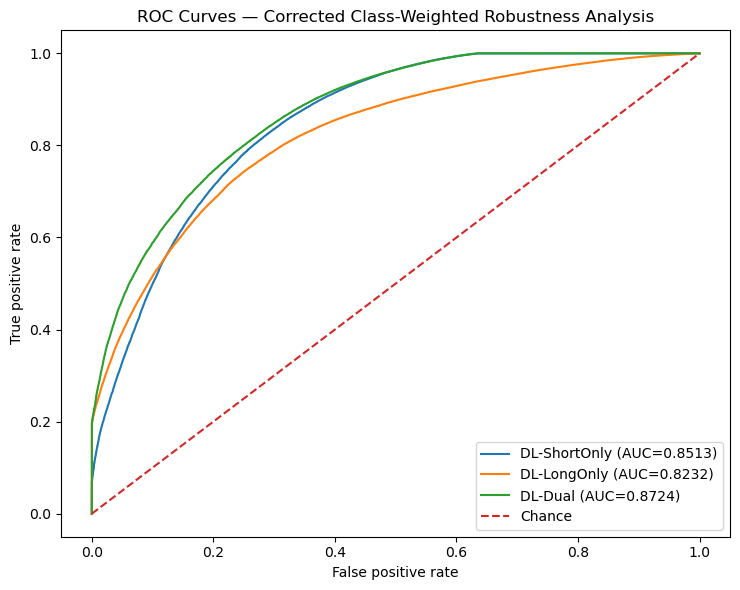

In [28]:
# -----------------------------------------------------------------------------
# R3 — REPORT CORRECTED IMBALANCE RESULTS
# Compares the class-weighted supplementary results with the locked primary
# results. ROC-AUC/PR-AUC assess ranking stability, while threshold-dependent F1
# and MCC are reported separately because they can respond strongly to weighting.
# -----------------------------------------------------------------------------
if not corrected_imbalance_results.empty:
    display(corrected_imbalance_results)

    primary_dual_row = primary_dl_results[
        primary_dl_results["Model"] == "DL-Dual"
    ].iloc[0]

    corrected_dual_row = corrected_imbalance_results[
        corrected_imbalance_results["Model"] == "DL-Dual"
    ].iloc[0]

    robustness_comparison = pd.DataFrame([
        {
            "Experiment": "Primary 75/25 training undersampling",
            "ROC_AUC": primary_dual_row["ROC_AUC"],
            "PR_AUC": primary_dual_row["PR_AUC"],
            "F1": primary_dual_row["F1"],
            "MCC": primary_dual_row["MCC"],
        },
        {
            "Experiment": "Corrected order-level class-weighted BCE",
            "ROC_AUC": corrected_dual_row["ROC_AUC"],
            "PR_AUC": corrected_dual_row["PR_AUC"],
            "F1": corrected_dual_row["F1"],
            "MCC": corrected_dual_row["MCC"],
        },
    ])

    robustness_comparison["ROC_AUC_difference_vs_primary"] = (
        robustness_comparison["ROC_AUC"] - float(primary_dual_row["ROC_AUC"])
    )

    save_table(robustness_comparison, "primary_vs_corrected_imbalance_robustness_dual_final")
    display(robustness_comparison)

    if corrected_imbalance_store:
        plt.figure(figsize=(7.5, 6))

        for model_name in ["DL-ShortOnly", "DL-LongOnly", "DL-Dual"]:
            if model_name not in corrected_imbalance_store:
                continue
            item = corrected_imbalance_store[model_name]
            y_true = np.asarray(item["y_true"])
            probabilities = np.asarray(item["probabilities"])
            fpr, tpr, _ = roc_curve(y_true, probabilities)
            auc_value = roc_auc_score(y_true, probabilities)
            plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_value:.4f})")

        plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
        plt.xlabel("False positive rate")
        plt.ylabel("True positive rate")
        plt.title("ROC Curves — Corrected Class-Weighted Robustness Analysis")
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.savefig(FIG_DIR / "fig7_corrected_class_weighted_robustness_roc.png", dpi=300, bbox_inches="tight")
        plt.show()


## R4. Supplementary traditional-ML feature-set comparison


In [29]:
# -----------------------------------------------------------------------------
# R4 — SUPPLEMENTARY TRADITIONAL-ML FEATURE-SET CHECK
# Evaluates an additional tabular feature configuration as a reviewer-facing
# fairness/diagnostic check. It is supplementary and does not redefine the
# manuscript's primary baseline experiment.
# -----------------------------------------------------------------------------
supplementary_ml_results = pd.DataFrame()

if RUN_SUPPLEMENTARY_ML_FAIRNESS:

    X_train_all = train_df_bal[all_tabular_cols].to_numpy(dtype=np.float32)

    X_test_all = test_df[all_tabular_cols].to_numpy(dtype=np.float32)

    supplementary_rows = []

    for model_name, estimator_template, use_scaling in baseline_models:

        estimator = clone(estimator_template)

        (
            fitted_estimator,
            fitted_scaler,
            probabilities,
            training_seconds,
            inference_seconds,
        ) = fit_predict_baseline(
            estimator,
            X_train_all,
            y_train_long,
            X_test_all,
            scale=use_scaling,
        )

        metrics = evaluate_probabilities(
            y_test_long,
            probabilities,
            threshold=FIXED_THRESHOLD,
        )

        metrics["Model"] = model_name

        metrics["Feature_Set"] = "CurrentShortPlusLong_SUPPLEMENTARY"

        metrics["Training_Time_s"] = training_seconds
        metrics["Inference_Time_s"] = inference_seconds

        supplementary_rows.append(metrics)

    supplementary_ml_results = pd.DataFrame(supplementary_rows)

    supplementary_ml_results = supplementary_ml_results.sort_values(
        "ROC_AUC",
        ascending=False,
    ).reset_index(drop=True)

    save_table(
        supplementary_ml_results,
        "supplementary_ml_short_plus_long_metrics",
    )

    display(supplementary_ml_results)

else:

    print("Supplementary ML fairness comparison is disabled.")


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\supplementary_ml_short_plus_long_metrics.csv


,ROC_AUC,PR_AUC,Average_Precision,Precision,Recall,F1,MCC,Threshold,Model,Feature_Set,Training_Time_s,Inference_Time_s
0,0.896671,0.991613,0.991504,0.970777,0.967766,0.969269,0.501082,0.5,Random Forest,CurrentShortPlusLong_SUPPLEMENTARY,128.503249,16.080350
1,0.895567,0.991519,0.991519,0.969537,0.969382,0.969460,0.492607,0.5,Gradient Boosting,CurrentShortPlusLong_SUPPLEMENTARY,281.261303,1.943213
2,0.825015,0.983666,0.983666,0.976916,0.782327,0.868859,0.271771,0.5,Logistic Regression,CurrentShortPlusLong_SUPPLEMENTARY,0.669549,0.087153


## R5. Reviewer-facing feature-importance figure


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\tree_based_feature_importance.csv


,Rank,Feature,Importance
0,1,cum_avg_days,0.562913
1,2,cum_order_count,0.312638
2,3,cum_reorder_ratio,0.039762
3,4,cum_std_days,0.036355
4,5,cum_avg_basket,0.024759
5,6,cum_std_basket,0.023573


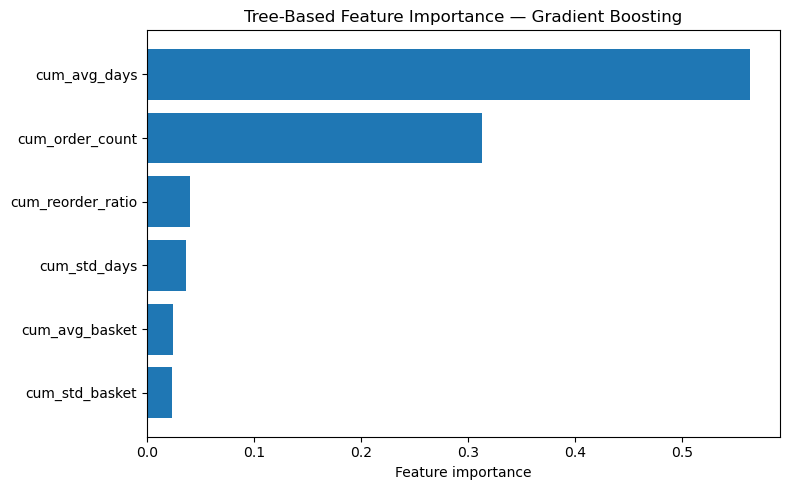

In [30]:
# -----------------------------------------------------------------------------
# R5 — TREE-BASED FEATURE IMPORTANCE
# Extracts impurity-based feature importance from the fitted Gradient Boosting
# baseline and creates a reviewer-facing figure. This is distinct from SHAP:
# both describe the traditional baseline, not the LSTM's hidden representation.
# -----------------------------------------------------------------------------
tree_model_name = "Gradient Boosting"
tree_model = primary_baseline_store[tree_model_name]["model"]

tree_importance = pd.DataFrame({
    "Feature": long_cols,
    "Importance": tree_model.feature_importances_,
}).sort_values("Importance", ascending=False).reset_index(drop=True)

tree_importance.insert(0, "Rank", np.arange(1, len(tree_importance) + 1))
save_table(tree_importance, "tree_based_feature_importance")
display(tree_importance)

plot_imp = tree_importance.sort_values("Importance", ascending=True)
plt.figure(figsize=(8, 5))
plt.barh(plot_imp["Feature"], plot_imp["Importance"])
plt.xlabel("Feature importance")
plt.title("Tree-Based Feature Importance — Gradient Boosting")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_tree_based_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()


## R6. Complete fold-level cross-validation output


All 10 Dual-Timescale GroupKFold folds completed:


,Fold,ROC_AUC,PR_AUC,Precision,Recall,F1,MCC,Training_Time_s,Inference_Time_s
0,1,0.875457,0.988934,0.960831,0.992331,0.976327,0.550276,101.953717,0.564303
1,2,0.874805,0.988828,0.960644,0.993247,0.976673,0.555468,111.412250,0.573915
2,3,0.871696,0.988603,0.959611,0.995374,0.977165,0.560850,110.207730,0.804429
3,4,0.869877,0.988410,0.958123,0.999862,0.978547,0.589745,108.275783,0.617642
4,5,0.869727,0.988340,0.958422,0.999347,0.978457,0.587385,110.596355,0.692063
5,6,0.867175,0.988072,0.957746,0.999967,0.978401,0.586091,115.558613,0.740755
6,7,0.869092,0.988243,0.958448,1.000000,0.978783,0.595695,115.330240,0.576124
7,8,0.866981,0.988108,0.958836,0.997291,0.977686,0.569666,117.255768,0.591243
8,9,0.869003,0.988143,0.958302,0.999542,0.978488,0.588141,118.147768,0.738585
9,10,0.876045,0.989048,0.958985,0.997162,0.977701,0.570305,121.399691,0.607603


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\dual_10fold_complete_fold_level_results.csv


,ROC_AUC,PR_AUC,Average_Precision,Precision,Recall,F1,MCC,Threshold,Fold,Model,Feature_Set,Training_Time_s,Inference_Time_s
0,0.843751,0.987310,0.987310,0.963618,0.935044,0.949116,0.323553,0.5,1,Gradient Boosting,LongOnly_PRIMARY,227.009262,0.514470
1,0.842891,0.987263,0.987263,0.963722,0.933202,0.948216,0.321183,0.5,2,Gradient Boosting,LongOnly_PRIMARY,221.636254,0.518170
2,0.839563,0.986978,0.986978,0.963314,0.932611,0.947714,0.315376,0.5,3,Gradient Boosting,LongOnly_PRIMARY,268.658030,0.518727
3,0.838941,0.986931,0.986931,0.962794,0.934377,0.948372,0.312672,0.5,4,Gradient Boosting,LongOnly_PRIMARY,246.902847,1.034054
4,0.841558,0.987132,0.987132,0.963124,0.936672,0.949714,0.320998,0.5,5,Gradient Boosting,LongOnly_PRIMARY,269.938221,0.503380
5,0.839732,0.986991,0.986991,0.963393,0.932126,0.947501,0.315379,0.5,6,Gradient Boosting,LongOnly_PRIMARY,261.134332,0.510707
6,0.842907,0.987289,0.987289,0.963481,0.933887,0.948453,0.319695,0.5,7,Gradient Boosting,LongOnly_PRIMARY,197.999203,0.628969
7,0.841263,0.987098,0.987098,0.963394,0.933798,0.948365,0.318514,0.5,8,Gradient Boosting,LongOnly_PRIMARY,197.283464,0.391282
8,0.841366,0.987090,0.987090,0.963242,0.933290,0.948030,0.315794,0.5,9,Gradient Boosting,LongOnly_PRIMARY,200.481399,0.413275
9,0.841873,0.987186,0.987186,0.963236,0.933130,0.947944,0.315422,0.5,10,Gradient Boosting,LongOnly_PRIMARY,197.834864,0.403748


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\baseline_10fold_complete_fold_level_results.csv


,Fold,Dual_ROC_AUC,Baseline_ROC_AUC,Paired_ROC_AUC_Difference,Baseline_Model
0,1,0.875457,0.843751,0.031706,Gradient Boosting
1,2,0.874805,0.842891,0.031914,Gradient Boosting
2,3,0.871696,0.839563,0.032133,Gradient Boosting
3,4,0.869877,0.838941,0.030936,Gradient Boosting
4,5,0.869727,0.841558,0.028168,Gradient Boosting
5,6,0.867175,0.839732,0.027443,Gradient Boosting
6,7,0.869092,0.842907,0.026185,Gradient Boosting
7,8,0.866981,0.841263,0.025718,Gradient Boosting
8,9,0.869003,0.841366,0.027636,Gradient Boosting
9,10,0.876045,0.841873,0.034172,Gradient Boosting


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\dual_vs_best_baseline_foldwise_roc_auc.csv


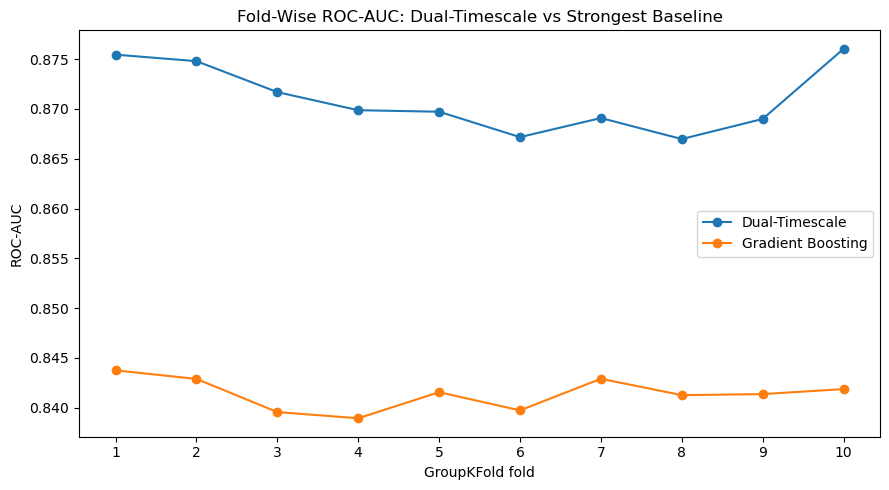

In [31]:
# -----------------------------------------------------------------------------
# R6 — COMPLETE FOLD-LEVEL CV OUTPUT
# Verifies that all expected folds are present and exports the individual fold
# results rather than reporting only means. This supports independent checking of
# the paired Dual-Timescale versus Gradient Boosting comparison.
# -----------------------------------------------------------------------------
if not dual_cv_results.empty:
    expected_folds = list(range(1, CV_FOLDS + 1))
    observed_folds = sorted(dual_cv_results["Fold"].astype(int).tolist())

    assert observed_folds == expected_folds, (
        f"Expected folds {expected_folds}, but observed {observed_folds}"
    )

    dual_fold_display_columns = [
        column for column in [
            "Fold",
            "ROC_AUC",
            "PR_AUC",
            "Precision",
            "Recall",
            "F1",
            "MCC",
            "Training_Time_s",
            "Inference_Time_s",
        ]
        if column in dual_cv_results.columns
    ]

    print("All 10 Dual-Timescale GroupKFold folds completed:")
    display(
        dual_cv_results[
            dual_fold_display_columns
        ].sort_values("Fold").reset_index(drop=True)
    )

    save_table(
        dual_cv_results.sort_values("Fold").reset_index(drop=True),
        "dual_10fold_complete_fold_level_results",
    )

if not baseline_cv_results.empty:
    baseline_fold_table = baseline_cv_results.sort_values(
        ["Model", "Fold"]
    ).reset_index(drop=True)

    display(baseline_fold_table)
    save_table(
        baseline_fold_table,
        "baseline_10fold_complete_fold_level_results",
    )

if not dual_cv_results.empty and not baseline_cv_results.empty:
    baseline_means_for_plot = (
        baseline_cv_results.groupby("Model")["ROC_AUC"]
        .mean()
        .sort_values(ascending=False)
    )
    strongest_baseline = baseline_means_for_plot.index[0]

    best_fold_auc = (
        baseline_cv_results[
            baseline_cv_results["Model"] == strongest_baseline
        ][["Fold", "ROC_AUC"]]
        .rename(columns={"ROC_AUC": "Baseline_ROC_AUC"})
    )

    dual_fold_auc = (
        dual_cv_results[["Fold", "ROC_AUC"]]
        .rename(columns={"ROC_AUC": "Dual_ROC_AUC"})
    )

    fold_comparison = dual_fold_auc.merge(
        best_fold_auc,
        on="Fold",
        how="inner",
    ).sort_values("Fold")

    fold_comparison["Paired_ROC_AUC_Difference"] = (
        fold_comparison["Dual_ROC_AUC"]
        - fold_comparison["Baseline_ROC_AUC"]
    )
    fold_comparison["Baseline_Model"] = strongest_baseline

    display(fold_comparison)
    save_table(fold_comparison, "dual_vs_best_baseline_foldwise_roc_auc")

    plt.figure(figsize=(9, 5))
    plt.plot(
        fold_comparison["Fold"],
        fold_comparison["Dual_ROC_AUC"],
        marker="o",
        label="Dual-Timescale",
    )
    plt.plot(
        fold_comparison["Fold"],
        fold_comparison["Baseline_ROC_AUC"],
        marker="o",
        label=strongest_baseline,
    )
    plt.xlabel("GroupKFold fold")
    plt.ylabel("ROC-AUC")
    plt.title("Fold-Wise ROC-AUC: Dual-Timescale vs Strongest Baseline")
    plt.xticks(range(1, CV_FOLDS + 1))
    plt.legend(loc="best")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "supplementary_10fold_dual_vs_best_baseline.png", dpi=300, bbox_inches="tight")
    plt.show()


## R7. Numerical SHAP importance table


In [32]:
# -----------------------------------------------------------------------------
# R7 — NUMERICAL SHAP SUMMARY
# Converts the previously computed SHAP values into mean absolute SHAP magnitude
# per long-term feature. Mean |SHAP| measures average importance magnitude; it
# should not be interpreted as the direction of a feature's effect.
# -----------------------------------------------------------------------------
if RUN_SHAP and "shap_values" in globals():
    shap_array = np.asarray(shap_values)

    if shap_array.ndim == 3:
        shap_array = shap_array[..., -1]

    if shap_array.ndim == 2 and shap_array.shape[1] == len(long_cols):
        shap_importance = pd.DataFrame({
            "Feature": long_cols,
            "Mean_Absolute_SHAP": np.abs(shap_array).mean(axis=0),
        }).sort_values(
            "Mean_Absolute_SHAP",
            ascending=False,
        ).reset_index(drop=True)

        shap_importance.insert(
            0,
            "Rank",
            np.arange(1, len(shap_importance) + 1),
        )

        save_table(
            shap_importance,
            "gradient_boosting_mean_absolute_shap_importance",
        )
        display(shap_importance)
    else:
        print(
            "SHAP values were generated, but their stored shape was not the "
            "expected 2D feature matrix. Inspect shape:",
            getattr(shap_array, "shape", None),
        )
else:
    print(
        "No reusable shap_values object is available. "
        "The SHAP figure from Section 22 remains valid; if needed, "
        "the final SHAP cell can be adjusted after this complete rerun."
    )


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\gradient_boosting_mean_absolute_shap_importance.csv


,Rank,Feature,Mean_Absolute_SHAP
0,1,cum_order_count,0.972798
1,2,cum_avg_days,0.772074
2,3,cum_std_basket,0.201818
3,4,cum_reorder_ratio,0.200748
4,5,cum_avg_basket,0.194231
5,6,cum_std_days,0.148259


## R8. Final output index


In [33]:
# -----------------------------------------------------------------------------
# R8 — FINAL OUTPUT INDEX
# Scans the generated table and figure directories and writes an index of outputs.
# This helps GitHub readers locate the exact artefacts produced by the notebook.
# -----------------------------------------------------------------------------
final_output_rows = []

for csv_path in sorted(TAB_DIR.glob("*.csv")):
    final_output_rows.append({
        "Type": "Table",
        "File": str(csv_path),
    })

for png_path in sorted(FIG_DIR.glob("*.png")):
    final_output_rows.append({
        "Type": "Figure",
        "File": str(png_path),
    })

final_output_index = pd.DataFrame(final_output_rows)
display(final_output_index)

save_table(
    final_output_index,
    "final_reviewer_github_output_index",
)

print("PRIMARY experiment remained fixed at T =", MAIN_T)
print("All final outputs are under:", OUT_DIR)


,Type,File
0,Table,C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis...
1,Table,C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis...
2,Table,C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis...
3,Table,C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis...
4,Table,C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis...
5,Table,C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis...
6,Table,C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis...
7,Table,C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis...
8,Table,C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis...
9,Table,C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis...


[saved] C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production\tables\final_reviewer_github_output_index.csv
PRIMARY experiment remained fixed at T = 50
All final outputs are under: C:\Users\t_jaf\OneDrive\Desktop\Mehwish\Thesis\final_outputs_production
